Dylan Ross

Perform basic differential expression analysis (Welch's t-test) to identify top features within each block for all mutation state comparisons.

## Setup

### Imports

In [17]:
import os
import pickle
from matplotlib import pyplot as plt, rcParams

import polars as pl
from scipy import stats

# set max font size 
rcParams["font.size"] = 7

### Constants

In [18]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "volcano"
)

# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [19]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)

    # load subset omics data
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # add the ∆z and t-test p-value columns
        .with_columns(
            pl.concat_list(wt_cols).alias("wt"),
            pl.concat_list(mut_cols).alias("mut"),
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        ).drop(
            "wt",
            "mut"
        )
    )

### NPM1 vs. WT

#### black patients

In [20]:
# proteomics
b_npm1_prot = load_data_add_delta_z_and_ttest_p("B_NPM1-WT", "Proteomics")
b_npm1_prot

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-09-1336,C-05-3084,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A2M""",0.930965,0.459289,-0.528668,0.514176,0.013901,0.013901,0.013901,0.013901,0.013901,0.013901,-2.303169,-0.896693,-2.101786,0.113138,-0.830806,-0.065829,-2.06473,-1.68516,-0.674612,-0.605204,-1.21044,-2.218202,-0.367419,0.035705,0.814287,-0.577459,1.139408,0.834313,1.26369,-0.863425,-0.186071,1.349073,-0.284062,-0.234173,0.98815,1.090308,1.162326,0.017735,1.175812,-0.450254,-0.780997,0.557054,0.523242,1.46517,-1.441206,0.013901,0.951646,0.989636,1.153037,0.962897,-0.329423,-0.168107,1.026487,1.842213,1.761581,0.689539,1.174962,-1.112657,-1.193886,0.146278,0.013901,0.013901,0.011587,-1.850595,-0.243775,-0.49672,0.156484
"""AAAS""",-1.567519,-1.413631,-0.417431,-0.977543,-0.144807,-0.144807,-0.144807,-0.144807,-0.144807,-0.144807,-1.993635,-1.140949,-0.934048,-1.64574,-0.175461,-0.426868,-1.534787,-0.821339,-0.732998,-0.368537,0.52688,-0.784121,-0.66395,0.199218,-0.311607,2.274093,0.88453,-0.270731,1.129186,0.413256,1.049048,0.176668,0.520246,0.869976,0.444867,-0.312438,-0.965621,1.073446,0.020224,1.597879,1.529943,0.352862,0.41403,-0.19513,-1.41533,0.017235,1.720644,0.19592,-0.163726,1.128081,1.21197,1.02845,0.111003,0.438768,1.073338,-1.278637,2.833083,-0.144807,-0.668324,-0.152713,-0.144807,-0.144807,-0.776879,-1.755609,1.933721,-0.273675,0.555769
"""AACS""",0.125508,1.077864,0.124253,0.359078,0.075653,0.075653,0.075653,0.075653,0.075653,0.075653,-2.237298,-2.108042,0.156919,-1.257847,-0.962289,-0.41583,-1.943027,-0.529407,-1.128678,0.668772,-0.705565,0.662467,0.774232,0.822295,-0.078683,-0.239746,-0.936879,-1.13158,-3.029894,0.008687,0.03081,0.075653,-0.242136,0.43161,0.220093,0.280635,0.17869,0.968748,0.509157,-1.054181,1.470811,-0.437935,-0.751552,1.671076,1.801567,0.139918,0.332937,2.096264,-0.549304,-0.095458,1.25223,1.105092,1.991598,1.032811,-0.327716,-0.277824,1.64842,-2.089546,0.395185,0.290992,0.075653,0.075653,-0.420342,-0.172413,-0.18642,0.009335,0.958205
"""AAGAB""",-0.501025,1.311362,0.264045,0.230094,-0.062079,-0.062079,-0.062079,-0.062079,-0.062079,-0.062079,-2.505099,-2.46317,-0.871753,-0.15604,-1.881483,-0.99235,-1.279106,-0.310077,-0.874163,-0.274701,0.401131,0.239332,-0.100875,0.199769,0.044122,-0.128491,1.187066,-0.528475,-1.199596,0.324503,-0.100945,-0.062079,-0.13242,0.990522,0.085907,-0.516071,0.353583,1.629349,0.197186,-0.725986,1.084086,-0.248684,-1.059998,2.150375,0.84566,0.947016,0.014843,2.11934,-0.076058,-1.026074,1.924983,-0.128552,2.443618,1.145907,-0.729197,0.168927,1.999587,-1.131386,0.142574,0.243797,-0.062079,-0.062079,-1.665274,-0.770673,0.247751,-0.308347,0.328716
"""AAK1""",-0.128119,1.252195,0.114879,0.067008,0.005752,0.005752,0.005752,0.005752,0.005752,0.005752,-1.789608,-2.181586,-0.805854,-0.359468,-1.460496,-1.357523,-1.308956,-0.01279,-0.971735,-0.350975,-0.777784,1.543249,0.188322,-1.245196,0.266054,-0.303428,-0.030795,-0.889047,-0.623128,0.241813,0.485868,0.616408,0.106398,0.063452,0.228851,-0.472527,-0.431926,1.755867,0.643986,-1.051108,0.005752,0.229542,-0.564564,1.483273,0.203976,0.548134,1.41751,1.752087,0.800303,-0.125504,2.865553,0.725202,2.371

In [21]:
# phosphoproteomics
b_npm1_phos = load_data_add_delta_z_and_ttest_p("B_NPM1-WT", "Phosphoproteomics")
b_npm1_phos

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-09-1336,C-05-3084,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.211065,-3.0472,-1.291025,-4.22699,0.211065,0.211065,0.211065,0.211065,0.211065,0.211065,-1.203183,-0.768872,0.394819,-0.782686,0.576393,-0.344535,-0.811499,-0.319695,-1.247025,-0.260215,0.284149,0.105728,-0.020872,0.881301,0.34235,1.826454,0.613168,0.671749,1.057526,0.55784,1.297368,0.435511,-0.124863,1.108749,0.545078,-0.388376,-0.319186,0.541662,0.080317,1.644649,0.18651,0.252029,0.407311,-0.910696,-0.552921,0.558188,0.235619,-0.039967,-0.041728,-0.336591,0.447235,0.373808,0.363436,0.11582,1.063558,-2.125894,1.004247,0.299508,-0.211202,-1.534187,0.211065,0.211065,0.931797,-1.594353,1.400301,-0.09374,0.841066
"""AAK1-S637s""",0.337942,0.236884,0.496598,-2.323244,-0.005133,-0.005133,-0.005133,-0.005133,-0.005133,-0.005133,-2.050485,-1.020804,0.101494,-1.17914,-0.005133,-0.518089,-0.72431,-1.12126,-1.740371,-0.184231,-0.659743,0.506434,-0.998622,-1.219923,0.763604,-0.016269,0.184869,-1.017311,0.684673,-0.003706,-0.583875,1.366459,-0.960877,0.032671,0.14579,-0.522193,-1.025561,1.420858,1.231387,-0.033752,-0.729166,0.509453,0.128631,2.620615,-0.006559,0.907642,2.076685,1.328489,1.743017,0.078701,2.368021,0.255044,2.190431,0.666115,-0.180337,-0.834485,-0.625183,-0.962846,1.128001,0.105042,-0.005133,-0.005133,-0.245601,-0.940365,-1.141047,-0.176786,0.586879
"""AAK1-T606t""",-0.268948,0.213853,1.000139,0.213262,-0.116348,-0.116348,-0.116348,-0.116348,-0.116348,-0.116348,-1.950547,-1.537269,-0.781979,-0.591016,-1.548523,-0.889215,-0.537612,0.223949,-0.849222,-0.368596,-0.814232,1.526868,-0.655943,-1.849369,0.448705,-0.111696,-0.295985,-1.430903,0.397518,0.583922,-0.116348,0.852054,-0.416352,-0.245717,0.155711,0.112654,-0.964145,1.621451,0.390312,-0.878134,0.185631,0.012516,-0.368633,0.882497,-0.421354,1.092342,1.526263,2.123716,1.518023,-0.148299,2.659503,0.522276,2.643143,1.156262,2.01376,-1.31801,-0.92806,-0.928236,0.297504,-0.145606,-0.116348,-0.116348,-1.257178,-0.817874,-0.00805,-0.346437,0.180926
"""AAK1-T620t""",0.145253,0.894225,1.37821,0.424119,-0.004468,-0.004468,-0.004468,-0.004468,-0.004468,-0.004468,-0.891206,-1.10708,0.410519,0.542413,-2.099898,-0.320584,-1.001631,0.658683,-0.81819,0.054822,-1.00417,0.625236,-0.162288,-0.646022,0.644737,-0.516555,-0.065307,-1.373601,-1.241175,-0.004468,0.028178,-0.142927,-0.660404,0.422578,-0.028627,-0.729212,-0.657661,1.575211,-0.121387,-0.856046,0.672533,0.116821,-1.42663,2.431888,0.309192,0.171335,0.590557,1.734017,0.664657,-1.177474,2.605897,0.667675,2.454758,1.421334,0.513746,-1.143438,-0.238812,-1.41152,0.848611,1.127539,-0.004468,-0.004468,-2.289835,-1.43954,-0.523309,-0.365901,0.467734
"""AAK1-T620tS624s""",-2.65277,0.520855,0.772511,0.2891,-0.012783,-0.012783,-0.012783,-0.012783,-0.012783,-0.012783,-1.728854,-1.489727,-0.421585,-0.505338,0.597966,-0.75545,-0.107877,-0.251995,-1.135954,0.057689,-0.669401,0.796971,-1.057859,-1.132953,0.080864,-0.104519,0.169341,-1.561025,0.078831,0.611569,-0.147978,0.826057,-0.875647,-0.020284,0.074242,-0.562913,-0.905341,1.510392,0.657972,-0.611641,0.413885,-0.122595,-0.012783,1.262629,-0.356072,1.334067

In [22]:
# lipidomics
b_npm1_lipid = load_data_add_delta_z_and_ttest_p("B_NPM1-WT", "Lipidomics")
b_npm1_lipid

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-09-1336,C-05-3084,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 20:4_[M-H]-__A""",0.037803,0.015719,-0.442416,0.015719,-1.644578,-1.535797,-0.849171,-0.129378,-1.895742,-1.687875,-0.618877,-0.588307,-0.995509,-0.514681,-1.507139,-1.917115,-0.085471,-1.144968,0.516209,0.665558,1.431515,0.445511,0.026599,0.905971,-0.764871,0.931503,0.454802,0.645154,-0.929113,-1.10907,3.324811,0.40462,-0.134961,0.221614,0.684336,0.402136,1.007987,0.886675,0.088677,-0.225346,-0.612008,0.122194,0.905151,0.120856,1.037126,-0.112854,1.535687,0.004839,-0.975211,-0.018752,1.312779,1.965016,1.19055,0.578727,1.708673,-0.700252,-1.093332,0.015719,0.015719,0.015719,-1.329567,-0.066051,-1.137861,0.962647,0.161951,-0.220527,0.519057
"""neg_LPG 22:6_[M-H]-__A""",1.106777,0.157645,0.756149,0.157645,-1.413508,-0.848931,-1.625053,-0.248627,-0.811672,0.472171,1.287657,0.332615,-0.474067,-1.115722,-1.269709,0.445505,-1.371848,-0.255936,1.254133,1.445658,0.602197,0.740431,1.410423,1.615876,0.201448,1.884283,0.954535,-0.713042,-0.969813,0.001223,0.589237,-1.199894,0.782087,-1.001471,1.158672,0.712394,0.309251,0.713028,1.018365,0.16153,0.138358,-3.017299,-0.762418,0.565968,0.113792,-0.006793,-0.479716,-0.619401,-0.647393,0.13419,0.245769,1.728212,0.40435,-1.509973,0.542413,0.834905,-1.196517,0.157645,0.157645,0.157645,-2.515828,0.335503,-0.420464,0.15376,-1.445993,-0.57279,0.220321
"""neg_LPG 22:5_[M-H]-__A""",-1.003826,0.088184,0.062626,0.088184,-2.431007,-2.154363,-0.826158,0.037789,-0.649627,1.353172,-0.543272,1.275742,-0.764986,-0.756511,0.355321,-0.081711,0.113742,-0.481529,0.340655,0.821486,0.476488,-0.418315,0.601415,1.224892,1.359073,0.510262,0.91419,0.376257,-0.882954,-0.76064,0.900148,-0.110494,0.230001,-0.129398,-0.434228,1.337921,0.614663,1.992648,1.082391,-1.448066,0.718863,-1.154883,0.568836,1.286483,0.048934,-0.514753,0.734121,-1.164928,-1.374675,0.425784,0.249942,1.997585,0.500589,-1.049373,-0.934797,-0.833349,-0.795429,0.088184,0.088184,0.088184,-3.285683,0.676836,0.408397,1.333626,-0.386845,-0.172474,0.773172
"""neg_LPS 18:1_[M-H]-__A""",0.18351,-0.190818,-0.81828,-0.190818,0.214491,0.474959,-0.718216,1.168354,-0.876946,-0.150536,-1.241234,-0.147042,-2.295903,-0.673824,-0.906904,-1.182887,-0.81274,-1.4339,-0.284411,-0.369393,-0.976312,-0.988105,-1.27147,-0.389334,-0.159276,-0.846201,1.239777,1.384173,-0.424502,-0.802963,1.078401,1.707475,-0.712376,-0.570001,1.146581,1.119198,1.292917,-1.24885,1.430179,-1.16667,-1.577271,0.692627,1.584319,1.643478,-0.340326,-0.121264,2.648348,0.974429,0.379038,0.707395,0.686933,0.297536,0.699017,1.253703,2.321367,-0.222361,0.208935,-0.190818,-0.190818,-0.190818,-0.280096,-0.29137,-0.403257,-0.15379,-0.72504,-0.35785,0.027543
"""neg_LPI 22:4_[M-H]-__A""",-0.538562,-0.003494,-0.175277,-0.003494,-0.003494,-0.066684,-0.003494,-0.930248,-0.003494,-0.003494,-0.031376,-1.861094,-0.691787,-0.570269,-0.187944,-0.85445,-1.82588,-1.863123,1.226465,0.276049,0.687327,-0.439093,-1.946139,1.251509,-1.300419,-0.343088,0.72661,0.595006,-0.865194,-0.888499,2.270453,1.023759,0.407426,1.105851,0.47141,0.783551,1.536039,0.238351,0.720828,-0.875094,-0.462128,-2.46299

In [23]:
# metabolomics
b_npm1_metab = load_data_add_delta_z_and_ttest_p("B_NPM1-WT", "Metabolomics")
b_npm1_metab

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-09-1336,C-05-3084,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.871702,-0.065365,-1.496804,-0.065365,-0.938974,-0.604997,-0.764405,-0.687294,-1.951821,-0.683525,-0.341193,0.323944,-0.274467,-1.899579,-1.355645,-0.797131,-1.733185,-0.13751,-0.583018,-1.076438,-0.276692,-0.147453,1.703813,-0.024416,-0.645997,0.76682,0.010407,-0.225949,-1.14166,-0.220984,0.072991,0.269301,0.492583,0.423297,0.234898,0.058966,0.19973,0.610443,1.654216,0.341889,-0.034429,0.716186,-0.182667,0.27864,0.953874,0.281927,0.850518,2.71964,0.727047,-0.457102,1.111637,1.416325,2.173657,1.762794,-0.096302,2.612893,0.686916,-0.065365,-0.065365,-0.065365,-1.335398,-1.213463,-1.444898,-0.218151,-1.008679,-0.856738,0.009606
"""rppos_5.Oxoproline""",0.761445,-0.11481,-0.065932,-0.11481,-1.156022,-1.791425,-0.494869,0.576205,-0.1422,0.396709,1.013739,0.740562,-0.550419,0.508828,-1.152405,-0.153751,1.02387,0.560108,0.315766,-1.293086,1.793119,-1.277053,1.480756,-1.377079,-0.144313,-0.194492,-0.068554,-3.368107,-0.245353,-1.280643,-0.422399,0.160184,0.494191,2.02858,-0.228274,-0.644493,-0.309964,1.59615,-0.693875,0.658663,1.278065,1.010684,-0.324021,0.926868,1.591027,1.548662,-0.542519,-0.327024,1.254247,-0.548915,1.836315,0.424841,-0.30775,0.750886,0.315912,-1.517103,-0.550661,-0.11481,-0.11481,-0.11481,-0.08742,-0.464289,-1.440216,0.017302,-1.325014,-0.565029,0.061713
"""rppos_Acetyl.L.carnitine""",1.811326,0.232953,-1.06704,0.232953,-2.639867,-0.542398,-1.189861,1.449965,-0.559505,0.377554,0.583694,0.602967,-0.145701,-1.219036,-1.471434,0.282977,0.525125,0.629861,0.218163,-2.045025,1.376661,0.024452,1.961673,-1.52004,-0.5267,0.014227,0.247744,-2.486312,-0.542766,-1.728766,-1.023736,0.476949,0.413857,0.002755,0.451825,0.086478,0.037614,0.632445,0.193167,-0.856858,0.539336,0.926916,1.446835,0.597717,0.343023,0.717929,-0.03891,1.75752,0.633209,-1.077518,0.49337,-0.195638,0.620436,1.017582,0.4227,-1.40022,0.522744,0.232953,0.232953,0.232953,0.902811,-1.297539,-0.153016,0.873907,-1.654395,-0.138057,0.740355
"""rppos_Adenosine""",-1.218961,-0.038032,1.124332,-0.038032,-1.834008,0.236341,-1.621842,-0.992003,-0.233584,-0.130455,-0.271285,-0.274586,-0.942399,-0.714673,-0.820357,-0.343753,0.182109,-0.780931,-0.608301,-2.014007,0.810068,-1.903977,0.158317,-1.407368,1.907552,-0.616408,0.914011,-1.5485,1.447546,-0.507723,-1.815205,1.196798,-0.286768,0.431935,0.835873,1.01961,0.213774,0.338791,0.421911,-0.100427,0.48402,1.304289,1.160025,0.99994,-0.033743,1.131872,1.267789,0.518967,1.539233,1.073836,-0.04232,-1.149753,-0.475855,1.605872,1.935369,-0.421225,1.06304,-0.038032,-0.038032,-0.038032,0.910538,-1.158537,0.367128,-1.000896,-1.140878,-0.336,0.345305
"""rppos_Arginine""",0.992127,0.06633,-0.64615,0.06633,-0.245569,-0.65945,-0.11067,-2.941971,0.805299,1.692168,0.15346,1.444085,0.143593,1.210886,0.620345,-1.815403,1.739976,1.422078,0.697434,0.050026,2.341894,0.350806,-0.458703,0.035691,0.406171,0.61204,0.905553,-1.954447,1.124763,-1.742785,0.787679,-3.132133,-0.225687,-0.257735,-0.288812,-0.484898,-0.880874,1.408691,-0.922344,0.502028,-2.039517,-0.286644,0.342939,-0.534853,-0.1

#### white patients

In [24]:
# proteomics
w_npm1_prot = load_data_add_delta_z_and_ttest_p("W_NPM1-WT", "Proteomics")
w_npm1_prot

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,15-00482,15-00051,15-00276,15-00302,15-00653,15-00855,16-00056,16-00886,16-00504,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00770,17-00834,17-01054,19-00092,16-01100-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-1.120712,0.559693,0.509441,-1.092024,2.115176,0.505511,-0.35066,-2.292624,0.755917,0.99725,0.887855,-0.536614,0.202024,-2.195447,-0.975754,0.643801,1.395539,-0.364754,-1.036813,-0.066231,-1.038048,0.11264,-0.752465,-0.080969,-0.080969,1.329033,0.17818,-0.325316,-0.337432,0.601645,-0.080969,0.822556,-0.832914,0.369056,-0.080969,-0.080969,…,-0.080969,2.882484,0.742085,1.121497,-1.986445,-0.488179,-0.769835,-0.368235,-0.080969,-0.080969,0.629619,1.418677,-1.031601,-0.292654,-1.671648,-0.348888,-0.080969,-0.16544,-0.916447,-0.080969,1.659495,-0.670049,-0.248601,0.326066,-0.677482,0.58812,0.186894,2.165707,1.577976,-1.197035,-0.080969,2.123743,-1.570688,-0.158679,-0.729561,0.030667,0.895818
"""A2M""",-0.645049,1.652101,0.656217,-1.223615,2.07074,0.046133,-1.360862,1.261334,-0.981207,1.989444,1.38015,1.126968,-0.195347,-0.404027,-1.129677,0.870149,1.177509,0.702726,-1.030546,0.027664,0.78199,-0.095451,-0.281378,0.795514,-0.812216,-0.042882,-0.56069,0.077096,-1.198138,3.00129,0.826018,-0.481681,-0.871139,0.443083,-1.59836,0.365776,…,-1.086976,2.686582,-0.359811,0.421092,-0.80656,-0.551992,-0.590998,-0.040188,-1.296593,1.649479,0.563176,0.841247,-1.111923,-0.492714,-2.034394,-0.369432,-0.638296,-0.351672,1.162318,-1.475426,0.379921,1.275077,-0.140934,1.126538,-0.696944,0.422628,-0.712251,0.289353,0.609577,-1.479869,1.836071,0.912377,-0.551094,-0.814283,-0.361819,-0.075539,0.746055
"""AAAS""",0.030761,1.399064,0.609426,-0.928379,0.022328,-0.034376,-2.402319,-2.01744,-0.151756,1.633452,1.111318,0.128096,0.451588,-0.445137,-1.585541,0.249108,0.703759,-0.767651,-0.951632,0.372298,-0.203209,0.689281,0.78313,1.367979,-1.906336,0.821236,0.847545,0.250625,-1.029745,-1.469132,-1.388439,-0.422609,-0.437779,-0.077003,-0.563093,-0.422342,…,-0.663477,-2.157879,-0.774188,1.068962,-0.604054,1.555145,-2.226617,-0.308976,-0.462863,1.71303,1.510332,0.870591,0.031587,-0.76457,-1.396271,0.273021,-1.288161,-0.16878,-0.667412,-0.94183,1.262147,-2.578698,0.792216,0.615189,1.132389,0.634947,-0.153854,0.237538,0.748446,-1.155784,0.940188,0.686234,-1.342254,-0.947444,0.503089,0.004296,0.985576
"""AACS""",0.07813,1.898765,0.930045,-1.195709,-0.137816,-0.481944,-2.371388,-1.402506,-0.01819,1.249069,0.881115,-0.106658,0.724629,-0.002164,-0.790637,-0.337542,0.325305,-0.404858,-0.670801,-0.469277,-0.528342,0.316998,1.16019,-0.319149,-1.127131,-0.492388,-0.252296,-0.645888,-0.958213,-0.906817,-2.00887,0.549092,-0.717205,1.215256,-1.148569,0.435566,…,-1.069696,-2.069872,-0.591218,-0.019467,0.644242,1.989462,-0.044668,0.333034,-0.841923,1.992072,0.948301,1.266173,-0.681241,-0.249042,-0.379809,1.604692,-0.735021,-0.040774,0.370725,-1.708815,1.679816,-1.918284,0.689695,1.455438,1.281812,-0.846586,-0.15247,1.074701,1.083111,-0.727126,0.736447,0.944014,0.197232,-0.234734,2.155406,0.463814,0.060855
"""AAGAB""",-0.007986,1.871435,1.174142,-0.736959,0.470591,0.505011,-2.042391,-1.716918,-0.307311,1.478371,0.697132,-0.319659,0.737242,-0.633375,-1.560299,-0.107885,1.032624,-0.52329,-0.8

In [25]:
# phosphoproteomics
w_npm1_phos = load_data_add_delta_z_and_ttest_p("W_NPM1-WT", "Phosphoproteomics")
w_npm1_phos

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,15-00482,15-00051,15-00276,15-00302,15-00653,15-00855,16-00056,16-00886,16-00504,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00770,17-00834,17-01054,19-00092,16-01100-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.260165,0.64747,-0.497741,0.201388,-2.217723,-0.819464,0.260165,0.260165,-2.205349,0.411746,-0.893708,-1.660894,0.781109,-1.599024,0.260165,0.189014,0.900518,-1.295862,0.232323,1.239565,0.62829,0.411746,0.260165,0.498364,0.260165,-0.021343,-0.794716,0.275632,-1.252553,-0.986513,0.244697,-1.698016,0.260165,0.399372,0.467429,-1.716577,…,0.260165,0.260165,0.260165,-1.685642,1.111464,1.362943,0.53499,-0.129116,1.150905,0.213762,-1.413415,-1.728951,0.847928,-0.107961,0.89928,-0.114148,0.260165,-0.330692,-0.169831,0.260165,0.83741,0.260165,1.088726,0.570751,0.679024,0.260165,-1.438163,0.260165,-2.16204,0.260165,0.260165,0.232323,0.781109,-0.145083,0.972115,0.12854,0.542785
"""AAK1-S20s""",0.059107,1.260091,0.619803,-0.635638,-0.206684,-0.439345,-1.909443,-1.456114,-0.594292,1.101047,-0.668764,-1.155167,1.186795,-0.588652,-1.442413,0.104824,1.480264,-0.624369,-0.444775,0.74002,0.198965,0.317574,1.542694,-0.098325,0.069881,0.019832,-0.511664,0.433177,-0.61886,-0.572445,-0.934224,0.60793,-1.535997,0.231993,-1.132513,-0.307862,…,-1.251556,-3.327301,-0.839577,1.019486,0.407829,0.069881,0.069881,-0.397173,-0.654286,2.378377,0.331615,1.001913,-0.954461,0.080655,0.397011,0.95018,-0.073589,-0.479854,0.247682,-1.22055,0.306603,-2.392436,-0.239185,0.808023,0.270701,-0.934383,-0.631391,0.643183,-0.495185,-2.480875,0.64031,0.559217,1.097097,0.069881,0.069881,-0.03642,0.876209
"""AAK1-S637s""",-0.425621,1.149321,0.089747,-0.564798,-2.093623,0.169387,-0.979158,-1.568343,-2.14005,1.721789,-0.041321,-0.85971,0.885525,0.144547,0.144547,0.749611,1.366068,-0.601268,-0.421977,1.1379,0.527823,0.603494,-0.931433,1.357073,-0.624111,-0.029944,-1.022281,0.732952,-0.287311,-1.300389,-0.708405,-0.845759,-0.617603,0.697239,0.369755,-2.518748,…,-1.375435,-1.458673,-1.518511,-1.553512,0.374002,0.810509,-0.644991,-0.40568,-0.125072,2.00711,0.112751,0.741703,0.070395,-0.027487,0.310252,1.306383,0.769599,1.000446,0.643529,-2.070982,1.436486,-2.33541,0.826634,1.621953,1.142121,0.586903,-0.822558,1.065782,-0.5167,0.430067,0.034742,0.853226,1.240328,-0.508834,0.846035,0.550514,0.019259
"""AAK1-S678s""",-0.387867,2.47986,-0.415242,-0.500693,-0.7867,-1.134549,-0.051794,-0.787074,-1.710459,0.779826,1.098508,0.269718,1.438292,-0.53795,-1.609888,0.265466,0.461125,-1.311097,-0.766177,0.41816,0.242249,1.407031,1.572612,-0.021466,-0.021466,-0.021466,-0.310349,0.547625,-1.82976,-1.460581,-1.425704,-1.419809,-0.365721,1.70643,-0.188935,-1.057958,…,-0.021466,-2.076949,-1.52829,-0.189663,-0.528782,0.939374,-0.784301,-1.024231,-0.676831,0.911196,-0.159155,2.244758,-0.823114,0.177679,-0.736492,-0.271831,-0.021466,-1.13577,0.760916,-0.021466,-0.021466,-2.756723,-0.06923,0.802471,1.446429,0.013129,-0.053272,1.005826,-0.845893,-0.77825,-0.021466,1.182483,0.308782,-0.021466,1.637671,0.107493,0.640847
"""AAK1-T606t""",-0.105441,1.556215,0.686078,-1.163525,0.912962,-1.033096,-2.776504,-1.062502,-0.502885,1.195584,0.715693,-0.627572,0.769442,-0.936295,-1.000666,-0.517846,0.913925,-1.022001,-0.

In [26]:
# transcriptomics
w_npm1_rna = load_data_add_delta_z_and_ttest_p("W_NPM1-WT", "Transcriptomics")
w_npm1_rna

/Users/dylan.ross/Library/CloudStorage/OneDrive-PNNL/Documents/projects/AML_disparities_cohort/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,15-00482,15-00051,15-00276,15-00302,15-00653,15-00855,16-00056,16-00886,16-00504,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00770,17-00834,17-01054,19-00092,16-01100-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""TSPAN6""",-0.309884,-0.561268,-0.309884,-0.078619,2.262494,-0.309884,-0.491795,-0.358983,0.226053,-0.473661,-0.244844,-0.37743,-0.493673,2.685781,0.000137,-0.506648,-0.309884,-0.561268,-0.309884,-0.309884,-0.503391,-0.208524,-0.309884,-0.45896,-0.305957,-0.218965,-0.561268,-0.400003,-0.309884,-0.420597,0.017361,-0.422104,-0.275001,-0.518206,-0.531919,-0.198057,…,0.438389,-0.153921,-0.503494,-0.309884,-0.309884,-0.309884,-0.309884,-0.309884,-0.309884,-0.561268,-0.561268,-0.335985,0.241023,-0.338463,-0.561268,-0.509595,-0.007647,-0.309884,-0.515625,0.578946,-0.309884,0.479871,3.279905,0.039748,-0.208329,0.29179,0.304492,-0.309884,-0.398849,-0.309884,-0.504199,-0.561268,0.081489,-0.309884,-0.309884,-0.100158,0.610736
"""DPM1""",-0.067879,0.357908,-0.067879,-0.171962,0.159611,-0.067879,-0.067879,-0.36597,-1.114903,-1.752748,1.524552,-0.59753,0.566649,-0.882435,-0.224007,1.259167,-0.067879,-1.602673,-0.067879,-0.067879,-0.479765,-0.219336,-0.067879,1.61709,-0.797584,-1.431786,0.643611,1.336604,-0.067879,-0.504967,-0.215464,-0.024298,0.240522,0.538092,-1.365722,-1.880326,…,0.017921,0.799051,-0.844898,-0.067879,-0.067879,-0.067879,-0.067879,-0.067879,-0.067879,-1.034509,0.110147,-0.222795,-0.269029,-1.360077,-0.836645,0.068395,-0.740971,-0.067879,0.401144,0.042061,-0.067879,1.410213,-1.183451,0.823074,-0.402375,-1.152608,-0.667606,-0.067879,0.337885,-0.067879,1.515364,-0.410875,-0.155856,1.332541,-0.067879,-0.145048,0.461348
"""SCYL3""",-0.041902,-0.417731,-0.041902,0.263279,-1.51745,-0.041902,-0.183494,-0.290174,-0.152989,-1.116158,0.242615,-1.642482,-1.105699,0.409972,-1.685311,-1.373574,-0.041902,-1.769312,-0.041902,-0.041902,2.065652,0.050734,-0.041902,-0.041902,0.243038,-0.690342,0.117775,-0.657331,-0.041902,0.248405,0.954217,-0.054291,1.020872,-0.414754,0.93539,-1.263761,…,1.514005,1.934855,-0.81808,-0.041902,-0.041902,-0.041902,-0.041902,-0.041902,-0.041902,-0.623635,2.071737,-0.109792,-0.316786,1.266022,2.183824,0.337219,0.880234,-0.041902,3.78335,0.41967,-0.041902,-1.489562,0.265445,-1.797062,1.451658,-0.479835,-0.875532,-0.041902,-0.605222,-0.041902,-1.21591,-1.308177,0.042856,0.604363,-0.041902,0.219051,0.402555
"""FIRRM""",-0.150292,-0.884031,-0.150292,2.390144,-0.001517,-0.150292,0.239407,-0.515013,1.868213,-0.301481,-1.220925,-1.508632,-1.204509,-1.220711,-1.40346,-1.351713,-0.150292,-0.041443,-0.150292,-0.150292,0.296807,0.050049,-0.150292,-0.47089,0.372205,-1.134886,0.794154,0.112458,-0.150292,0.34851,1.809324,-0.630203,-0.386702,0.499428,1.795074,-0.850636,…,2.131706,-0.26161,0.340439,-0.150292,-0.150292,-0.150292,-0.150292,-0.150292,-0.150292,-0.547318,-0.60431,-0.367931,-0.937795,0.455672,1.596463,0.887962,1.148742,-0.150292,-0.339897,0.827379,-0.150292,-1.014895,-0.694993,-1.612741,0.643581,-1.035192,-1.218822,-0.150292,0.397522,-0.150292,-1.476257,-1.43294,-0.181778,3.251163,-0.150292,-0.163411,0.493068
"""FGR""",-0.342027,0.885541,-0.342027,-0.839306,0.511422,-0.342027,-0.826777,1.355827,0.783535,1.255896,-0.370047,-0.070135,-0.71

### NRAS vs. WT

#### black patients

In [27]:
# proteomics
b_nras_prot = load_data_add_delta_z_and_ttest_p("B_NRAS-WT", "Proteomics")
b_nras_prot

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,C-98-0846,C-09-1906,C-05-1287,C-04-1098,C-09-5381,C-05-0569,C-04-1647,C-99-0740,C-12-2943,C-95-068,C-01-1665,C-05-3159,C-98-0031,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-0.690143,1.918891,-0.613173,0.879533,0.072007,0.072007,0.072007,0.072007,0.072007,0.072007,-2.359034,-1.849761,-1.406722,-0.164292,-1.058455,-1.753554,-2.120025,-0.744655,-0.869048,-1.498537,-1.52075,-1.210571,-0.866339,-0.947829,-0.669613,-0.883096,1.054198,0.149043,0.645776,-0.457073,-0.157331,0.371934,-0.248161,0.144921,0.473732,0.041417,0.283056,0.490816,0.734289,-0.19369,-0.171692,0.494428,0.6122,0.186724,-0.562685,0.665142,1.108749,1.427469,1.228513,1.239185,0.072007,-0.255057,1.393938,2.393197,1.343253,0.133365,2.290579,-1.711949,0.127261,-0.722408,-0.553628,-0.041326,-0.654566,0.283834,1.081952,0.302439,1.049386,0.616207,0.855358,-0.838776,1.269105,0.261291,0.301481
"""A2M""",0.836525,0.355997,-0.6505,0.411915,-0.037742,-0.037742,-0.037742,-0.037742,-0.037742,-0.037742,-2.458302,-1.025432,-2.253139,0.003351,-0.958307,-0.178975,-2.215388,-1.828695,-0.799183,-0.728472,-1.345066,-2.37174,-0.486225,-0.075536,0.717658,-0.700207,1.04888,0.738059,1.175494,-0.991539,-0.301474,1.262479,-0.401303,-0.350479,0.894783,0.998858,1.072228,-0.093843,1.085967,-0.570614,-0.907564,0.455597,0.42115,1.380755,-1.580162,-0.097749,0.857595,0.896297,1.062764,0.869056,-0.447516,-0.283172,0.93384,1.764874,1.682729,0.590568,1.085101,-1.245448,1.171519,-1.228349,-0.037742,0.233564,-0.210393,0.864826,0.796615,-0.03892,0.229883,1.141123,-0.231719,-1.058602,1.338155,0.279665,0.302515
"""AAAS""",-1.523617,-1.369511,-0.371893,-0.932802,0.00997,0.00997,0.00997,0.00997,0.00997,0.00997,-1.95034,-1.09644,-0.889245,-1.60195,-0.129578,-0.381343,-1.490839,-0.776376,-0.687909,-0.322929,0.573762,-0.739105,-0.618762,0.245633,-0.265918,2.323462,0.931921,-0.224984,1.176926,0.459976,1.096673,0.223052,0.567119,0.917346,0.491632,-0.26675,-0.920863,1.121106,0.066385,1.646285,1.578253,0.399496,0.460751,-0.149276,-1.371212,0.063392,1.769225,0.242331,-0.117827,1.175819,1.259827,1.076045,0.157294,0.485525,1.120998,-1.234324,2.883248,-0.098881,-1.080007,-1.872795,0.591067,-0.885761,1.002051,0.669887,0.00997,-1.45577,-0.035527,-0.343392,-1.99328,0.085671,0.26726,-0.474648,0.134182
"""AACS""",0.141803,1.090672,0.140552,0.374518,0.092131,0.092131,0.092131,0.092131,0.092131,0.092131,-2.212353,-2.083569,0.173099,-1.236488,-0.942012,-0.397553,-1.919159,-0.510714,-1.107791,0.683078,-0.686227,0.676796,0.788152,0.836039,-0.06164,-0.222114,-0.916695,-1.110683,-3.002047,0.02541,0.047452,0.092131,-0.224495,0.446784,0.236041,0.296363,0.19479,0.981956,0.524048,-1.033567,1.482181,-0.419577,-0.732046,1.681713,1.811726,0.15616,0.348473,2.105344,-0.530538,-0.078354,1.2644,1.117801,2.001062,1.045784,-0.309761,-0.260052,1.65914,-2.065142,0.759857,-1.957149,-0.111521,-0.7568,0.230389,0.300632,0.866066,0.147744,-0.692588,-0.216705,-0.164515,0.698723,-0.017812,-0.086036,0.735797
"""AAGAB""",-0.526723,1.34927,0.265197,0.230055,-0.086841,-0.086841,-0.086841,-0.086841,-0.086841,-0.086841,-2.601128,-2.557728,-0.910461,-0.16963,-1.955627,-1.03529,-1.33211,-0.329073,-0.912956,-0.29245

In [28]:
# phosphoproteomics
b_nras_phos = load_data_add_delta_z_and_ttest_p("B_NRAS-WT", "Phosphoproteomics")
b_nras_phos

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,C-98-0846,C-09-1906,C-05-1287,C-04-1098,C-09-5381,C-05-0569,C-04-1647,C-99-0740,C-12-2943,C-95-068,C-01-1665,C-05-3159,C-98-0031,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.231383,-2.465365,-0.965681,-3.472845,0.231383,0.231383,0.231383,0.231383,0.231383,0.231383,-0.890669,-0.51979,0.473943,-0.531586,0.628998,-0.157428,-0.55619,-0.136216,-0.928108,-0.085423,0.379436,0.227074,0.118964,0.889373,0.429137,1.696486,0.660402,0.710427,1.039861,0.613155,1.244673,0.508692,0.030161,1.083602,0.602256,-0.194865,-0.13578,0.599339,0.205375,1.541234,0.296058,0.352008,0.484611,-0.6409,-0.335378,0.613452,0.337994,0.102658,0.101154,-0.150644,0.518704,0.456,0.447143,0.235692,1.045012,-1.678617,0.994363,0.392552,-4.352394,-1.956205,0.606908,-0.579995,0.923724,0.071868,-0.003673,-0.928329,0.517291,0.364532,-1.539528,-0.399754,-0.558633,-0.737702,0.090391
"""AAK1-S637s""",0.322629,0.222047,0.480538,-2.326032,-0.020251,-0.020251,-0.020251,-0.020251,-0.020251,-0.020251,-2.054556,-1.029721,0.087294,-1.187312,-0.020251,-0.529373,-0.734623,-1.129705,-1.745902,-0.197086,-0.67036,0.490328,-1.007644,-1.227904,0.746287,-0.029915,0.170276,-1.026245,0.667728,-0.017411,-0.594849,1.346305,-0.970077,0.018795,0.131382,-0.533457,-1.034456,1.400448,1.211869,-0.047315,-0.739456,0.493333,0.114303,2.594558,-0.020251,0.889647,2.053188,1.308514,1.721091,0.064608,2.343153,0.240122,2.166399,0.649257,-0.19321,-0.84428,-0.635962,-0.972036,-2.296278,-0.142873,-0.469029,-0.662842,-0.171187,0.596693,0.872189,1.093041,-0.020251,-0.041401,-0.689538,0.900407,0.73786,-0.02761,0.92476
"""AAK1-S670sT674tS678s""",-0.075408,-0.075408,0.63811,-0.075408,-0.075408,-0.075408,-0.075408,-0.075408,-0.075408,-0.075408,-1.31892,-0.785258,0.640121,-0.359588,-1.078423,-0.749274,-0.134563,-0.232127,-0.790159,0.23782,-0.490116,0.742249,-2.981142,-0.882876,0.164374,0.15266,0.196482,-0.79366,1.044735,0.152238,0.379651,1.34331,-0.367709,-0.00394,0.260438,-0.608389,-1.032849,1.204947,1.803649,-0.725517,-0.366354,-0.075408,-0.128557,1.23494,0.034493,0.549185,1.709878,1.795852,1.523035,-0.121764,2.772596,0.157039,1.688365,-0.468089,1.902994,-1.728952,-2.200574,-0.938992,-0.075408,-1.288744,-0.666469,-0.733913,0.635224,0.973542,0.462649,-0.797031,-1.217903,-0.572503,-1.192904,1.098045,1.088126,-0.215381,0.46323
"""AAK1-T606t""",-0.220671,0.231915,0.968995,0.231362,-0.077621,-0.077621,-0.077621,-0.077621,-0.077621,-0.077621,-1.797035,-1.409619,-0.701596,-0.522584,-1.420169,-0.802121,-0.472522,0.24138,-0.764631,-0.314083,-0.731831,1.462761,-0.583447,-1.702188,0.45207,-0.073261,-0.246016,-1.30991,0.404086,0.578826,-0.077621,0.830178,-0.35885,-0.198894,0.177412,0.13705,-0.872363,1.551425,0.397332,-0.791734,0.20546,0.043179,-0.314118,0.858715,-0.363539,1.055428,1.462194,2.022258,1.454469,-0.107572,2.524515,0.521037,2.509178,1.115348,1.919183,-1.204082,-0.838535,-0.8387,-2.288555,-1.973653,-1.230809,-1.085287,0.447367,0.889076,0.188549,-0.383995,-0.410305,0.125082,-0.347991,1.228642,0.989541,-0.362753,0.290908
"""AAK1-T620t""",0.170274,0.884339,1.345767,0.436143,0.027531,0.027531,0.027531,0.027531,0.027531,0.027531,-0.817879,-1.023691,0.423177,0.548924,-1

In [29]:
# lipidomics
b_nras_lipid = load_data_add_delta_z_and_ttest_p("B_NRAS-WT", "Lipidomics")
b_nras_lipid

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,C-98-0846,C-09-1906,C-05-1287,C-04-1098,C-09-5381,C-05-0569,C-04-1647,C-99-0740,C-12-2943,C-95-068,C-01-1665,C-05-3159,C-98-0031,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 20:4_[M-H]-__A""",-0.042031,-0.017462,-0.505866,-0.017462,-1.66701,-1.561941,-0.898742,-0.203508,-1.909605,-1.70883,-0.676306,-0.646779,-1.040087,-0.575665,-1.534261,-1.930249,-0.161099,-1.184447,0.420052,0.564305,1.304128,0.351766,-0.052853,0.796516,-0.817318,0.821177,0.36074,0.544598,-0.975957,-1.149773,3.132827,0.31227,-0.2089,0.135509,0.582443,0.309872,0.895051,0.777879,0.007107,-0.296201,-0.669671,0.03948,0.795724,0.038189,0.923196,-0.187547,1.404747,-0.07387,-1.020482,-0.096657,1.189444,1.819427,1.071386,0.480437,1.57183,-0.754904,-1.134572,-0.017462,-1.957657,1.140933,0.318573,0.157331,0.222457,-0.46283,0.522857,0.983899,-1.046943,-0.141819,1.450673,-0.094455,1.994398,0.290725,0.375398
"""neg_LPG 22:6_[M-H]-__A""",0.97068,0.122809,0.649388,0.122809,-1.338738,-0.821398,-1.532584,-0.271321,-0.787257,0.38917,1.136426,0.261291,-0.477899,-1.065868,-1.206971,0.364735,-1.300564,-0.278018,1.105707,1.281208,0.508317,0.634985,1.248921,1.437184,0.141098,1.683133,0.831175,-0.696879,-0.932167,-0.042375,0.496441,-1.142997,0.673156,-0.961176,1.018233,0.609294,0.239882,0.609875,0.889665,0.10452,0.083286,-2.808344,-0.742124,0.475119,0.060776,-0.04972,-0.483075,-0.611073,-0.636722,0.079467,0.181711,1.540121,0.327023,-1.427133,0.453535,0.721555,-1.139902,0.122809,-3.73982,0.485783,1.54809,-0.07854,1.274742,-0.360451,-0.354948,1.164968,-0.925785,-0.592027,1.423709,-0.898001,0.231082,-0.077328,0.852778
"""neg_LPI 20:3_[M-H]-__A""",0.994198,-0.003181,0.157906,-0.003181,0.378949,-0.003181,-0.003181,-0.998314,-0.871628,-0.003181,-0.021533,-1.032703,-0.488436,-1.552824,-1.400487,-1.499502,-0.797351,-1.137709,0.668879,0.617364,0.517123,-0.678666,0.374174,0.819809,-1.425792,0.070987,2.298293,0.249135,-0.469942,-0.264834,4.136885,0.281659,-0.547812,0.696947,0.993237,0.632789,0.94728,-0.278036,-0.138144,0.089975,-1.620584,-2.103811,1.365475,-0.43424,-0.004402,0.648842,1.005863,0.076074,-0.609368,-0.290009,-0.22121,1.523013,-0.348888,-1.177212,1.931984,0.19911,-1.033496,-0.003181,-1.453756,1.436931,0.505618,0.195747,-0.003181,-0.308971,-0.440484,0.104239,-0.814456,-1.090295,0.17145,0.328507,1.15872,-0.019768,0.941519
"""neg_LPG 22:5_[M-H]-__A""",-0.926276,0.156632,0.052456,0.156632,-2.236067,-1.982178,-0.763222,0.029662,-0.601212,1.23685,-0.503605,1.165788,-0.707082,-0.699305,0.321076,-0.080009,0.099367,-0.446941,0.307616,0.748896,0.432276,-0.388926,0.546927,1.119121,1.242265,0.463272,0.833976,0.34029,-0.815346,-0.703093,0.821089,-0.106425,0.206063,-0.123773,-0.40353,1.222853,0.559086,1.823726,0.988341,-1.333976,0.654715,-1.064908,0.517028,1.175646,0.03989,-0.477431,0.668718,-1.074128,-1.266622,0.385742,0.224365,1.828257,0.454395,-0.968077,-0.862925,-0.769822,-0.735021,0.156632,-4.282451,0.211972,0.997927,0.37037,1.5659,0.970527,-0.710799,1.142594,-1.289644,0.591856,0.12108,0.192184,-0.821265,-0.088491,0.84157
"""neg_LPI 18:1_[M-H]-__A""",0.254694,0.12062,-0.566932,0.12062,0.12062,0.12062,0.12062,-0.680233,0.12062,0.12062,0.790184,-

In [30]:
# metabolomics
b_nras_metab = load_data_add_delta_z_and_ttest_p("B_NRAS-WT", "Metabolomics")
b_nras_metab

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,C-98-0846,C-09-1906,C-05-1287,C-04-1098,C-09-5381,C-05-0569,C-04-1647,C-99-0740,C-12-2943,C-95-068,C-01-1665,C-05-3159,C-98-0031,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.716722,-0.049374,-1.662845,-0.049374,-1.10241,-0.766873,-0.927025,-0.849555,-2.119986,-0.845767,-0.501837,0.166406,-0.434799,-2.0675,-1.521027,-0.959904,-1.900329,-0.297203,-0.744791,-1.240516,-0.437034,-0.307193,1.552719,-0.183581,-0.808065,0.611351,-0.148594,-0.386055,-1.306042,-0.381066,-0.085719,0.111508,0.335832,0.266224,0.076945,-0.099809,0.041612,0.454243,1.502891,0.184435,-0.19364,0.56048,-0.342571,0.120891,0.799278,0.124193,0.69544,2.57329,0.571392,-0.618287,0.957778,1.263889,2.024757,1.611976,-0.255802,2.466044,0.531073,-0.049374,-1.405527,-1.147066,-0.81696,-0.392129,1.099014,0.177556,-0.013029,1.096618,1.207364,0.522242,0.220175,1.579376,1.194946,0.312869,0.312745
"""rppos_5.Oxoproline""",0.599285,-0.101804,-0.198209,-0.101804,-1.248929,-1.861383,-0.611655,0.420736,-0.271723,0.247722,0.842468,0.579156,-0.665199,0.355792,-1.245443,-0.282857,0.852232,0.40522,0.169703,-1.381043,1.593698,-1.365589,1.292618,-1.462002,-0.27376,-0.322127,-0.200737,-3.381121,-0.37115,-1.369049,-0.541802,0.01974,0.341683,1.820655,-0.354688,-0.755875,-0.433428,1.403843,-0.803474,0.500216,1.097246,0.839523,-0.446978,0.758734,1.398906,1.358071,-0.657584,-0.449872,1.074288,-0.663749,1.635334,0.274839,-0.431294,0.589108,0.169844,-1.596969,-0.665432,-0.101804,-0.742831,0.817899,-0.005399,-0.259492,0.044127,1.399179,1.609976,0.985511,1.887654,-0.524593,0.876596,-0.435245,-1.67551,0.374574,0.256048
"""rppos_Acetyl.L.carnitine""",1.772344,0.170526,-1.148777,0.170526,-2.744967,-0.616343,-1.273422,1.405615,-0.633703,0.317275,0.526477,0.546036,-0.213753,-1.303032,-1.559178,0.221293,0.467038,0.57333,0.155516,-2.141289,1.331222,-0.041072,1.924924,-1.608506,-0.600412,-0.051449,0.185537,-2.589131,-0.616715,-1.820332,-1.10483,0.418146,0.354117,-0.063092,0.392649,0.021875,-0.027715,0.575952,0.130149,-0.935473,0.48146,0.874797,1.402439,0.540708,0.282231,0.662705,-0.105375,1.717738,0.576727,-1.159411,0.434811,-0.264432,0.563764,0.96681,0.363091,-1.486907,0.464621,0.170526,-0.353131,-0.140016,-0.387618,0.776906,-0.008042,1.65942,1.23822,0.530306,0.74393,-0.534498,1.401881,-0.981916,-0.9991,0.277441,0.337401
"""rppos_Adenosine""",-1.300501,-0.038708,1.001779,-0.038708,-1.904784,0.12933,-1.696331,-1.077516,-0.332371,-0.231047,-0.369412,-0.372655,-1.02878,-0.80504,-0.908874,-0.440612,0.076046,-0.870138,-0.70053,-2.081632,0.693015,-1.973528,0.052671,-1.48561,1.77129,-0.708494,0.795139,-1.624273,1.319335,-0.601712,-1.88631,1.072976,-0.384624,0.3215,0.718368,0.898889,0.107157,0.229987,0.311652,-0.201545,0.372674,1.178585,1.036847,0.879563,-0.136027,1.009187,1.142725,0.407008,1.409418,0.952166,-0.144455,-1.232504,-0.570401,1.47489,1.79862,-0.516728,0.941559,-0.038708,1.40476,-0.444075,-0.863664,0.546047,-0.882107,-0.199482,1.547564,1.875505,0.794519,0.232267,0.830554,-1.111616,-0.130088,0.339009,0.277791
"""rppos_Arginine""",0.923547,0.069263,-0.675271,0.069263,-0.284338,-0.68825,-0.152688,-2.915795,0.741219,1.606727,0.10508

#### white patients

In [31]:
# proteomics
w_nras_prot = load_data_add_delta_z_and_ttest_p("W_NRAS-WT", "Proteomics")
w_nras_prot

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,17-00500,17-00678,17-00676,17-00763,17-00878,17-00881,17-00896,18-00103,18-00105,18-00190,18-00203,18-00218,18-00290,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,14-00127,14-00193,14-00712,15-00377,15-00578,15-00813,15-00976,16-00751,16-01191,16-01220,17-00072,17-00901,18-00408,16-01191-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-1.121872,0.595768,0.544402,-1.092548,2.185717,0.540385,-0.334758,-2.319751,0.79634,1.04302,0.931201,-0.524831,0.230173,-2.220421,-0.973703,0.681739,1.450134,-0.349163,-1.036114,-0.044026,-1.037377,0.138809,-0.745466,-0.048434,-0.048434,1.382154,0.205801,-0.308852,-0.321236,0.638649,-0.048434,0.864456,-0.827697,0.400906,-0.048434,-0.048434,…,0.11649,-0.048434,-0.131598,-0.048434,1.340252,0.475523,-2.472768,1.044669,0.91106,1.164539,-1.090254,0.329477,-0.065338,-0.048434,2.970027,0.782201,1.17002,-2.006788,-0.475323,-0.76322,-0.352722,-0.048434,0.313661,-0.048434,-0.26305,-0.409594,-0.730241,-0.346546,0.724103,1.577289,-2.604304,-0.112906,-0.048434,-0.048434,0.956138,-0.093817,0.742598
"""A2M""",-0.65365,1.698652,0.678858,-1.246107,2.127343,0.054127,-1.386649,1.298504,-0.997879,2.044095,1.420173,1.160912,-0.193151,-0.406841,-1.149913,0.897927,1.212666,0.726484,-1.048402,0.035214,0.807651,-0.090857,-0.281248,0.8215,-0.824831,-0.037025,-0.567265,0.085833,-1.220018,3.080234,0.852736,-0.48636,-0.885168,0.460607,-1.629849,0.381444,…,0.250711,-0.995062,-0.129135,0.133184,0.071536,1.192127,-0.137078,1.930023,0.636489,0.50796,0.109818,-0.636135,-1.15532,-1.106187,2.75797,-0.361563,0.438088,-0.819039,-0.558359,-0.598301,-0.034267,-0.488027,0.595656,0.780405,-0.185509,0.159927,0.482323,-1.935348,-0.146521,0.594961,-1.974985,-0.591918,1.040626,0.094029,-0.388813,-0.169098,0.543962
"""AAAS""",0.064053,1.430991,0.642141,-0.89413,0.055629,-0.001019,-2.3666,-1.982105,-0.118282,1.665145,1.143533,0.161291,0.484461,-0.41137,-1.550636,0.282182,0.73638,-0.733562,-0.917359,0.405249,-0.169683,0.721916,0.815672,1.399937,-1.871111,0.853739,0.880022,0.283698,-0.995395,-1.434343,-1.353731,-0.388865,-0.40402,-0.043603,-0.529209,-0.388598,…,1.066742,-0.585976,1.169106,1.676812,1.038752,0.251748,-0.477276,1.249834,0.087302,1.418589,-0.556626,0.480338,-0.040088,-0.629492,-2.122403,-0.740093,1.101218,-0.570128,1.586916,-2.191072,-0.275345,0.485239,0.320922,0.59039,0.829727,1.338993,0.233603,-2.018841,-0.291711,-0.060883,-1.59401,0.725258,0.518186,-1.455829,-1.804064,-0.188033,0.561644
"""AACS""",0.170445,2.119524,1.082462,-1.193263,-0.060736,-0.429141,-2.451884,-1.414648,0.06733,1.423993,1.03008,-0.027379,0.862553,0.084486,-0.759613,-0.274553,0.435058,-0.346617,-0.631322,-0.415581,-0.478813,0.426165,1.328843,-0.254861,-1.119846,-0.440322,-0.183292,-0.604651,-0.939011,-0.883989,-2.06379,0.674633,-0.681,1.387794,-1.142797,0.553097,…,2.167131,-0.593033,-1.256561,1.674249,0.549525,0.109126,-0.864576,0.463025,-0.925079,2.204697,-0.72038,-0.156335,0.357846,-1.058359,-2.129097,-0.546125,0.065962,0.776496,2.21662,0.038984,0.443332,1.348273,0.184427,1.063325,-0.459502,0.70708,0.131157,-0.561707,-1.085141,0.705875,-1.512223,0.418716,2.244499,-0.256737,0.765562,0.318147,0.290756
"""AAGAB""",-0.00279,1.917118,1.204803,-0.747465,0.486097,0.521259,-2.081019,-1.748535,-0.308563,1.515586,0.717517,-0.321176,0.758492,-0.641651,-1.588542,-0.10484,1.060237,-0.529194,-0.894103,-0.044066,-0

In [32]:
# phosphoproteomics
w_nras_phos = load_data_add_delta_z_and_ttest_p("W_NRAS-WT", "Phosphoproteomics")
w_nras_phos

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,17-00500,17-00678,17-00676,17-00763,17-00878,17-00881,17-00896,18-00103,18-00105,18-00190,18-00203,18-00218,18-00290,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,14-00127,14-00193,14-00712,15-00377,15-00578,15-00813,15-00976,16-00751,16-01191,16-01220,17-00072,17-00901,18-00408,16-01191-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",0.058327,1.284786,0.630916,-0.651155,-0.213101,-0.450697,-1.951979,-1.489034,-0.608931,1.122369,-0.684983,-1.181704,1.209935,-0.603172,-1.475042,0.105014,1.50963,-0.639646,-0.456243,0.753684,0.201152,0.322277,1.573383,-0.102444,0.041523,0.018219,-0.52455,0.440332,-0.63402,-0.586621,-0.956074,0.618792,-1.570612,0.23488,-1.158569,-0.316426,…,1.1369,-0.011927,-0.86223,1.261848,1.374806,0.351188,-0.668575,0.43445,0.465525,1.183333,-0.135268,0.700267,-0.608011,-1.280137,-3.399912,-0.859419,1.039077,0.414446,0.041523,0.041523,-0.407631,0.984931,0.597319,0.024718,0.927375,1.158715,0.198666,-1.151973,-1.133908,0.584921,-1.215639,0.448393,-0.092978,-1.869172,0.041523,-0.042818,0.880953
"""AAK1-S637s""",-0.259992,1.413917,0.287761,-0.407915,-2.032809,0.372405,-0.848313,-1.474521,-2.082154,2.022357,0.148456,-0.721359,1.133544,0.11305,0.11305,0.989089,1.644284,-0.446677,-0.25612,1.401777,0.753365,0.83379,-0.797589,1.634723,-0.470955,0.160548,-0.894145,0.971383,-0.112991,-1.18973,-0.560546,-0.706531,-0.464039,0.933426,0.585364,-2.484648,…,1.403448,0.843315,-0.934916,0.512676,0.640742,-1.81071,-0.062921,-1.204102,0.524398,1.141976,-0.094063,0.346004,-0.017415,-1.269491,-1.357959,-1.421558,-1.458759,0.589878,1.053814,-0.493147,-0.238799,0.233347,0.395101,0.075735,0.820581,1.21603,-0.240491,-2.02711,-0.402686,-0.627969,0.09527,0.757538,0.780427,-1.571264,-0.812058,-0.112625,0.690122
"""AAK1-S678s""",-0.355825,2.551295,-0.383576,-0.470201,-0.760137,-1.112764,-0.015135,-0.760516,-1.696585,0.827908,1.150968,0.310793,1.495419,-0.50797,-1.594632,0.306483,0.504829,-1.291737,-0.739332,0.461274,0.282947,1.463729,1.631584,-0.015135,-0.015135,-0.015135,-0.277242,0.592518,-1.817525,-1.443274,-1.407919,-1.401942,-0.333375,1.767241,-0.15416,-1.03512,…,2.160246,-0.015135,-0.015135,1.276201,0.388328,0.015609,-0.538322,-0.236787,-0.015135,1.878565,0.237726,0.755013,0.110516,-0.015135,-2.068109,-1.511914,-0.154898,-0.498676,0.989648,-0.757705,-1.000931,-0.015135,1.015645,-0.015135,-0.057869,1.930878,0.388123,-2.31342,-0.054822,-0.143688,-1.105937,0.225574,-0.015135,-0.015135,-0.043891,-0.018945,0.946931
"""AAK1-T606t""",-0.095105,1.630055,0.726664,-1.193627,0.962219,-1.058213,-2.868249,-1.088742,-0.507739,1.255642,0.757411,-0.63719,0.813213,-0.957712,-1.024544,-0.523271,0.963218,-1.046694,-0.355775,0.304253,-0.241179,0.814323,1.07218,0.769744,-1.465946,1.011698,0.301495,0.087041,-1.47273,-2.102664,-0.614699,0.461449,-0.948259,-0.115816,-1.176843,-0.037981,…,1.030345,0.373726,-0.994511,1.382994,1.2408,0.885306,0.30905,0.666675,-0.020435,0.985586,-0.376513,-0.520963,-0.48106,-0.80839,-2.899896,-0.622694,1.139232,0.700675,0.396811,-0.570355,0.413582,0.751674,0.238952,0.51905,0.919396,1.417715,2.256121,-1.487493,-1.371415,0.022016,-0.948259,0.978114,0.640853,-1.085723,-0.081545,0.238546,0.463664
"""AAK1-T620t""",0.692937,1.355886,0.179587,-0.330961,-0.444143,-0.411447,0.000273,-1.385382,-1.186609,2.020459,0.000273,-0.466898,-0.072304,-1.147215,-1.891874,1.082761,0.9713

In [33]:
# transcriptomics
w_nras_rna = load_data_add_delta_z_and_ttest_p("W_NRAS-WT", "Transcriptomics")
w_nras_rna

/Users/dylan.ross/Library/CloudStorage/OneDrive-PNNL/Documents/projects/AML_disparities_cohort/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Library/CloudStorage/OneDrive-PNNL/Documents/projects/AML_disparities_cohort/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Library/CloudStorage/OneDrive-PNNL/Documents/projects/AML_disparities_co

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,17-00500,17-00678,17-00676,17-00763,17-00878,17-00881,17-00896,18-00103,18-00105,18-00190,18-00203,18-00218,18-00290,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,14-00127,14-00193,14-00712,15-00377,15-00578,15-00813,15-00976,16-00751,16-01191,16-01220,17-00072,17-00901,18-00408,16-01191-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""TSPAN6""",-0.330975,-0.531453,-0.330975,-0.053115,2.267083,-0.330975,-0.4626,-0.330975,0.248834,-0.444628,-0.217856,-0.349257,-0.464462,2.686589,0.024937,-0.47732,-0.330975,-0.531453,-0.330975,-0.330975,-0.474093,-0.18186,-0.330975,-0.430058,-0.278422,-0.192208,-0.531453,-0.371628,-0.330975,-0.392038,0.042007,-0.393532,-0.247743,-0.488775,-0.502366,-0.171486,…,-0.330975,-0.531453,3.613786,-0.330975,4.308688,-0.233927,0.772269,-0.260688,0.075604,-0.531453,-0.330975,-0.340888,-0.419356,0.459274,-0.127744,-0.474195,-0.330975,-0.330975,-0.330975,-0.330975,-0.330975,-0.531453,0.103802,-0.252714,-0.531453,-0.381163,-0.138802,-0.33514,-0.330975,0.455425,-0.330975,-0.4891,-0.497187,0.764397,-0.330975,-0.243443,0.152046
"""DPM1""",-0.049855,0.272079,-0.049855,-0.229656,0.084311,-0.049855,-0.131099,-0.413362,-1.122529,-1.726505,1.376776,-0.632627,0.469736,-0.902405,-0.278938,1.125483,-0.049855,-1.584399,-0.049855,-0.049855,-0.521115,-0.274515,-0.049855,1.464401,-0.822058,-1.422586,0.542612,1.198808,-0.049855,-0.544979,-0.270848,-0.089833,0.160926,0.442696,-1.36003,-1.84731,…,-0.049855,-0.147512,0.896087,-0.049855,0.497051,0.376852,2.074309,2.446823,0.685084,1.030589,-0.049855,0.652385,0.649717,-0.049855,0.689798,-0.866861,-0.049855,-0.049855,-0.049855,-0.049855,-0.049855,1.788841,0.867974,1.483594,-0.724003,-0.312298,0.344635,0.126139,-0.049855,-1.386553,-0.049855,-0.15882,-1.257806,-0.032363,-0.049855,0.0508,0.852663
"""SCYL3""",0.034233,-0.406131,0.034233,0.378228,-1.67274,0.034233,-0.136347,-0.259215,-0.101212,-1.210549,0.354427,-1.816746,-1.198502,0.547182,-1.866075,-1.50703,0.034233,-1.962824,0.034233,0.034233,2.454125,0.133427,0.034233,0.026734,0.354916,-0.720112,0.210642,-0.682091,0.034233,0.361096,1.17402,0.012464,1.250792,-0.402702,1.152336,-1.380552,…,0.034233,2.444192,-0.441242,0.034233,2.966836,-0.896662,-0.740028,0.405038,0.310812,-0.198337,0.034233,0.471903,0.977454,1.818761,2.303478,-0.867235,0.034233,0.034233,0.034233,0.034233,0.034233,1.27652,-1.699652,-0.785652,0.786916,0.138286,0.582591,0.264063,0.034233,-0.242426,0.034233,0.407777,-1.324369,0.149559,0.034233,-0.029603,0.905724
"""FIRRM""",-0.109402,-0.9913,-0.109402,2.435629,-0.067614,-0.109402,0.184551,-0.605066,1.889348,-0.381572,-1.343912,-1.645042,-1.326729,-1.343687,-1.534963,-1.480802,-0.109402,-0.109402,-0.109402,-0.109402,0.244629,-0.013641,-0.109402,-0.558885,0.323544,-1.253859,0.765179,0.051679,-0.109402,0.298744,1.827712,-0.725629,-0.470768,0.456703,1.812796,-0.956348,…,-0.109402,0.822279,0.490807,-0.109402,1.969318,-0.778846,-1.188643,2.925571,0.352951,0.255376,-0.109402,0.925157,1.967972,2.165133,-0.33984,0.290297,-0.109402,-0.109402,-0.109402,-0.109402,-0.109402,0.602866,-1.088695,2.325199,1.006327,-0.310795,-0.545618,-0.247515,-0.109402,-0.307874,-0.109402,0.189903,-1.512896,-0.421286,-0.109402,-0.055005,0.844003
"""FGR""",-0.310177,0.698592,-0.310177,-0.896134,0.352697,-0.310177,-0.88455,1.133401,0.604282,1.041009,-0.462275,-0.184989,-0.779825,-0.550995,0.860041,-0.7497

### FLT3-ITD vs. WT

#### black patients

In [34]:
# proteomics
b_flt3itd_prot = load_data_add_delta_z_and_ttest_p("B_FLT3-ITD-WT", "Proteomics")
b_flt3itd_prot

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-0.597139,1.918461,-0.522926,0.916324,0.012408,0.012408,0.012408,0.012408,0.012408,0.012408,-2.206264,-1.715229,-1.288056,-0.09012,-0.952261,-1.622467,-1.975815,-0.649699,-0.769637,-1.376583,-1.398,-1.09893,-0.767025,-0.845596,-0.577344,-0.783182,1.084734,0.211995,0.690939,-0.372415,-0.083407,0.426903,-0.170985,0.20802,0.525056,0.108223,0.341209,0.541528,0.776282,-0.118465,-0.097255,0.545011,0.658565,0.248326,-0.474245,0.709611,1.137332,1.444638,1.252807,1.263097,0.137717,-0.177634,1.412307,2.375781,1.363438,0.196878,2.276839,-1.582352,0.012408,0.012408,-1.28831,-1.761456,0.539287,-0.506849,0.23612,1.152573,-0.866627,1.24598,-0.550769,1.241798,-0.05365,0.867292
"""A2M""",0.854255,0.392647,-0.574219,0.446363,-0.021895,-0.021895,-0.021895,-0.021895,-0.021895,-0.021895,-2.31084,-0.934389,-2.113756,0.053886,-0.869907,-0.121261,-2.077491,-1.706024,-0.717048,-0.649122,-1.241438,-2.227687,-0.416413,-0.021895,0.740067,-0.621969,1.058248,0.759665,1.179877,-0.901831,-0.238936,1.263437,-0.334835,-0.286012,0.910218,1.010196,1.080677,-0.039481,1.093875,-0.497479,-0.821162,0.488325,0.455235,1.377056,-1.467277,-0.043233,0.874494,0.911673,1.071586,0.885505,-0.379228,-0.221355,0.947738,1.74605,1.667139,0.617982,1.093043,-1.145742,0.89017,-0.021895,-1.438473,-1.579549,-0.328867,-0.865263,0.788655,0.786405,0.28863,1.339577,-1.141397,1.41417,0.013292,0.968979
"""AAAS""",-1.651169,-1.49971,-0.519238,-1.070507,0.000854,0.000854,0.000854,0.000854,0.000854,0.000854,-2.070557,-1.231333,-1.027699,-1.728155,-0.281088,-0.528526,-1.618954,-0.91677,-0.829823,-0.471116,0.410164,-0.880139,-0.761865,0.087675,-0.415085,2.129793,0.762168,-0.374854,1.002962,0.298334,0.924089,0.065482,0.403635,0.747844,0.329446,-0.415903,-1.058774,0.948101,-0.088492,1.464255,1.397392,0.238894,0.299096,-0.300447,-1.501382,-0.091434,1.585082,0.084429,-0.269538,1.001874,1.084439,0.903816,0.000854,0.323444,0.947995,-1.366848,2.679959,-0.250918,0.404305,0.000854,-0.017197,-1.280364,0.967395,0.952043,-1.137566,2.032342,-1.582915,1.514106,0.348932,0.892048,0.311176,0.388544
"""AACS""",0.111043,1.022063,0.109841,0.334474,0.111043,0.111043,0.111043,0.111043,0.111043,0.111043,-2.149211,-2.025565,0.14109,-1.212271,-0.929542,-0.4068,-1.867712,-0.515448,-1.088708,0.630727,-0.683959,0.624695,0.73161,0.777587,-0.084286,-0.238359,-0.905234,-1.091485,-2.907406,-0.000708,0.020455,0.063351,-0.240645,0.403858,0.201522,0.259437,0.161916,0.917683,0.47804,-1.017445,1.397955,-0.427946,-0.727951,1.589529,1.714356,0.124827,0.309468,1.996262,-0.53448,-0.100333,1.188861,1.04811,1.896139,0.978966,-0.32251,-0.274783,1.567856,-2.007872,0.565014,0.111043,-1.02465,-1.263197,0.793886,0.887987,0.512699,-0.971384,0.277558,-1.689704,0.738406,1.355029,0.029437,0.927167
"""AAGAB""",-0.562804,1.233559,0.195502,0.161852,-0.051497,-0.051497,-0.051497,-0.051497,-0.051497,-0.051497,-2.549158,-2.5076,-0.930254,-0.220869,-1.931056,-1.049784,-1.334005,-0.373543,-0.932643,-0.33848,0.331376,0.171007,-0.166191,0.131794,-0.0224

In [35]:
# phosphoproteomics
b_flt3itd_phos = load_data_add_delta_z_and_ttest_p("B_FLT3-ITD-WT", "Phosphoproteomics")
b_flt3itd_phos

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.18572,-3.248794,-1.411468,-4.483101,0.18572,0.18572,0.18572,0.18572,0.18572,0.18572,-1.319567,-0.865187,0.352277,-0.87964,0.542241,-0.421242,-0.909784,-0.395254,-1.365435,-0.333026,0.236493,0.049827,-0.082623,0.861238,0.297383,1.850066,0.580716,0.642004,1.045607,0.522831,1.296531,0.39485,-0.191419,1.099196,0.509479,-0.467109,-0.394721,0.505905,0.023242,1.659861,0.134342,0.202889,0.365346,-1.013565,-0.639257,0.523195,0.18572,-0.1026,-0.104442,-0.412931,0.407115,0.330295,0.319444,0.060385,1.051918,-2.284916,0.989866,0.252562,0.18572,0.18572,0.390692,-0.339399,0.81995,0.575158,-0.161035,1.653313,-1.389439,1.039793,-0.355199,0.127938,0.274892,0.308231
"""AAK1-S637s""",0.332349,0.229269,0.49418,-2.382097,-0.017591,-0.017591,-0.017591,-0.017591,-0.017591,-0.017591,-2.103879,-1.05359,0.091169,-1.215095,-0.017591,-0.540814,-0.751162,-1.156056,-1.787558,-0.200274,-0.685303,0.504213,-1.030964,-1.256695,0.76653,-0.028951,0.176212,-1.050027,0.686019,-0.016136,-0.607917,1.381451,-0.992464,0.020969,0.136352,-0.545,-1.058443,1.436938,1.243675,-0.046783,-0.756115,0.507293,0.118849,2.660707,-0.019047,0.913451,2.105891,1.342721,1.765545,0.06792,2.403058,0.247793,2.221913,0.66709,-0.196302,-0.863543,-0.650051,-0.994472,1.135287,-0.017591,-0.465421,-0.934571,-0.293605,0.574531,-1.171128,-0.780838,0.381792,0.695179,-0.290704,0.757391,-0.041203,0.873285
"""AAK1-S670sT674tS678s""",0.031611,0.031611,0.591572,0.031611,0.031611,0.031611,0.031611,0.031611,0.031611,0.031611,-1.420123,-0.871554,0.59364,-0.433994,-1.172909,-0.834565,-0.202684,-0.302973,-0.876592,0.180101,-0.568168,0.698621,-3.128777,-0.971899,0.104604,0.092563,0.137609,-0.880191,1.009556,0.092129,0.325894,1.316472,-0.442342,-0.068411,0.203351,-0.689745,-1.126062,1.174243,1.789669,-0.810145,-0.440949,-0.141877,-0.19651,1.205075,-0.028906,0.500164,1.693279,1.781654,1.501217,-0.189527,2.785682,0.097064,1.671166,-0.545526,1.891789,-1.841609,-2.326405,-1.029583,0.752227,0.031611,-0.902243,-1.270451,0.288713,0.898475,-0.820616,-0.871748,0.530207,0.744937,0.100878,0.33842,-0.018062,0.944955
"""AAK1-T606t""",-0.278479,0.186495,0.943749,0.185926,-0.067093,-0.067093,-0.067093,-0.067093,-0.067093,-0.067093,-1.897988,-1.499969,-0.772568,-0.588656,-1.510808,-0.875844,-0.537224,0.196218,-0.837328,-0.374448,-0.80363,1.451029,-0.651185,-1.800545,0.412675,-0.127034,-0.304518,-1.397531,0.363378,0.5429,-0.131514,0.801131,-0.42044,-0.256106,0.130499,0.089032,-0.948008,1.54212,0.356438,-0.865172,0.159315,-0.007408,-0.374484,0.83045,-0.425258,1.032547,1.450446,2.025839,1.44251,-0.162285,2.541843,0.48353,2.526087,1.094107,1.919943,-1.288806,-0.913255,-0.913424,1.174127,-0.067093,-1.670333,-1.582253,0.447748,0.463814,-1.740059,-0.448161,-0.067093,0.897613,0.352589,0.897361,-0.134945,0.686598
"""AAK1-T620t""",0.117807,0.912284,1.425674,0.413615,0.007749,0.007749,0.007749,0.007749,0.007749,0.007749,-0.981625,-1.210615,0.399189,0.539097,-2.263754,-0.376334,-1.098759,0.662431,-0.904173,0.021881,-1.101452,0.

In [36]:
# metabolomics
b_flt3itd_metab = load_data_add_delta_z_and_ttest_p("B_FLT3-ITD-WT", "Metabolomics")
b_flt3itd_metab

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.777953,-0.082536,-1.656979,-0.082536,-1.083504,-0.740161,-0.904039,-0.824766,-2.124756,-0.820891,-0.468958,0.214832,-0.400361,-2.07105,-1.511861,-0.937683,-1.899989,-0.259563,-0.717565,-1.224823,-0.402648,-0.269785,1.633401,-0.143297,-0.782311,0.67013,-0.107497,-0.350482,-1.291874,-0.345378,-0.043159,0.158657,0.388201,0.316973,0.12329,-0.057576,0.087135,0.509367,1.582413,0.233281,-0.15359,0.618076,-0.305987,0.168259,0.86243,0.171637,0.756175,2.677717,0.629242,-0.588117,1.024617,1.33785,2.116421,1.694036,-0.217199,2.567976,0.587984,-0.082536,-0.082536,-1.464537,-0.879754,-0.542724,-0.495436,0.725442,-0.201054,0.70677,1.160557,0.138454,1.622317,0.357907,0.105141,0.720146
"""rppos_5.Oxoproline""",0.679944,-0.069335,-0.179441,-0.069335,-1.311702,-1.971686,-0.624972,0.487538,-0.25866,0.301098,0.941999,0.658253,-0.682671,0.417554,-1.307945,-0.270657,0.952521,0.470819,0.217024,-1.454069,1.751529,-1.437415,1.427083,-1.54131,-0.260855,-0.312974,-0.182164,-3.609364,-0.365802,-1.441144,-0.549698,0.055423,0.402351,1.996099,-0.348063,-0.780384,-0.432913,1.54694,-0.831677,0.573186,1.21655,0.938826,-0.447515,0.851767,1.54162,1.497616,-0.674465,-0.450633,1.19181,-0.681109,1.796396,0.330319,-0.430613,0.668977,0.217176,-1.686751,-0.682922,-0.069335,-0.069335,-1.049252,0.613319,1.016884,-0.164683,-0.059143,-0.079527,-0.434577,0.657586,0.941471,0.599376,0.315043,0.23003,0.315961
"""rppos_Acetyl.L.carnitine""",1.736174,0.17778,-1.165332,0.17778,-2.750803,-0.636473,-1.28914,1.371908,-0.653717,0.290876,0.498673,0.5181,-0.236586,-1.31855,-1.572977,0.195538,0.439633,0.545211,0.130203,-2.151179,1.298014,-0.065065,1.88773,-1.621974,-0.620649,-0.075372,0.160022,-2.596014,-0.636843,-1.832378,-1.12168,0.39107,0.32747,-0.086937,0.365744,-0.002541,-0.051797,0.547816,0.105006,-0.95346,0.453958,0.844654,1.368753,0.512809,0.256067,0.633987,-0.128936,1.681935,0.548585,-1.175894,0.407623,-0.286925,0.53571,0.936049,0.336384,-1.501191,0.437233,0.17778,0.17778,-0.9098,-0.904534,0.250732,-0.489085,0.066154,0.158447,0.909227,1.351395,0.562088,1.821109,1.242624,0.426048,0.152542
"""rppos_Adenosine""",-1.308734,0.067524,1.012772,0.067524,-1.918063,0.133037,-1.707869,-1.083886,-0.332519,-0.230349,-0.36987,-0.373139,-1.034744,-0.809135,-0.913836,-0.441663,0.079309,-0.874777,-0.703752,-2.096388,0.70143,-1.987381,0.055738,-1.495389,1.788709,-0.711783,0.804406,-1.635209,1.33298,-0.604109,-1.899434,1.084563,-0.385208,0.326813,0.726994,0.909023,0.11068,0.234535,0.316882,-0.2006,0.378413,1.191055,1.048133,0.889536,-0.134536,1.020242,1.154895,0.413035,1.423815,0.962745,-0.143034,-1.240169,-0.572537,1.489834,1.816267,-0.518415,0.952049,0.067524,0.067524,-0.665278,0.198353,-0.411873,-0.945864,-1.118875,0.386399,0.828064,0.904437,1.928446,0.529582,1.465153,0.318426,0.308436
"""rppos_Arginine""",0.819944,0.102658,-0.538153,0.102658,-0.20608,-0.549178,-0.094251,-2.441341,0.665068,1.400264,0.124707,1.194608,0.116528,1.001292,0.511745,-1.507439,1.439895,1.1

In [37]:
# lipidomics
b_flt3itd_lipid = load_data_add_delta_z_and_ttest_p("B_FLT3-ITD-WT", "Lipidomics")
b_flt3itd_lipid

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 20:4_[M-H]-__A""",-0.016667,-0.037358,-0.481258,-0.037358,-1.644295,-1.539055,-0.874774,-0.178407,-1.887285,-1.686183,-0.651975,-0.6224,-1.01635,-0.55117,-1.51133,-1.907963,-0.135929,-1.160945,0.44617,0.590658,1.331687,0.377773,-0.027506,0.823247,-0.793218,0.847949,0.386761,0.570918,-0.952115,-1.126215,3.163367,0.338212,-0.183808,0.161162,0.608825,0.33581,0.921943,0.80458,0.032552,-0.271252,-0.64533,0.064978,0.822454,0.063684,0.950134,-0.16242,1.43247,-0.048558,-0.996712,-0.071381,1.216816,1.847826,1.098565,0.506653,1.599826,-0.730702,-1.110989,-0.037358,-0.037358,-0.047209,-1.715951,0.11277,1.785438,-0.264332,1.56667,-0.944217,0.386906,1.654442,-0.667212,-0.076705,0.176332,0.607541
"""neg_LPG 22:6_[M-H]-__A""",1.103229,0.14917,0.753617,0.14917,-1.409748,-0.846809,-1.62068,-0.248246,-0.809658,0.470463,1.283583,0.331311,-0.473032,-1.112826,-1.266366,0.443873,-1.36821,-0.255533,1.250157,1.441127,0.600111,0.737944,1.405994,1.610851,0.200525,1.878479,0.951427,-0.711313,-0.96734,0.00088,0.587189,-1.196754,0.779479,-0.998907,1.154973,0.709989,0.308015,0.710621,1.015072,0.160722,0.137617,-3.008889,-0.760547,0.563988,0.113123,-0.007113,-0.478664,-0.617945,-0.645855,0.133462,0.244717,1.722861,0.402838,-1.505934,0.540501,0.832145,-1.193386,0.14917,0.14917,0.448085,-0.018216,0.05492,-0.602884,0.414611,1.533611,-2.597818,-1.072602,-0.306115,0.196765,-1.724164,-0.354489,0.314377
"""neg_LPI 20:3_[M-H]-__A""",0.977639,-0.058222,0.15674,-0.058222,0.373715,-0.058222,-0.058222,-0.978197,-0.853843,-0.058222,-0.019395,-1.011953,-0.477704,-1.5225,-1.372967,-1.47016,-0.780933,-1.115026,0.658308,0.607742,0.509345,-0.664432,0.369028,0.80646,-1.397806,0.071422,2.25773,0.24629,-0.45955,-0.258218,4.06248,0.278216,-0.535987,0.68586,0.976696,0.622883,0.931585,-0.271177,-0.13386,0.09006,-1.589013,-2.063345,1.342083,-0.424505,-0.002579,0.638641,0.989089,0.076415,-0.59641,-0.282929,-0.215397,1.49672,-0.340725,-1.153802,1.898164,0.197186,-1.012731,-0.058222,-0.058222,-0.854017,-1.036227,0.630049,1.731672,-0.058222,1.1819,-0.069349,-0.647938,0.876695,-0.514913,-1.147442,0.003418,0.99101
"""neg_LPG 22:5_[M-H]-__A""",-0.954399,0.146124,0.043864,0.146124,-2.290327,-2.031372,-0.788091,0.020615,-0.622848,1.251894,-0.523293,1.179414,-0.730831,-0.722898,0.317845,-0.091244,0.091711,-0.465498,0.304116,0.754203,0.431264,-0.406326,0.548203,1.131816,1.257417,0.462878,0.84098,0.337442,-0.841256,-0.726762,0.827835,-0.118187,0.200537,-0.135882,-0.421221,1.237618,0.560604,1.850481,0.998426,-1.370234,0.658141,-1.095798,0.517707,1.189468,0.031048,-0.496597,0.672424,-1.105201,-1.301536,0.383802,0.219203,1.855103,0.453824,-0.997034,-0.889784,-0.794823,-0.759327,0.146124,0.146124,0.833998,-1.258844,0.079122,0.88226,1.029319,1.536388,-3.167298,0.772457,0.289351,1.014399,-2.544766,-0.038971,0.932073
"""neg_LPI 18:1_[M-H]-__A""",0.318305,0.066968,-0.518021,0.066968,0.066968,0.066968,0.066968,-0.633348,0.066968,0.066968,0.863374,-0.660186,-2.979712,-2.140222,-1.354336,-1.648219,0.06

In [38]:
# acetylomics
b_flt3itd_acetyl = load_data_add_delta_z_and_ttest_p("B_FLT3-ITD-WT", "Acetylomics")
b_flt3itd_acetyl

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCE1-K431k""",0.008695,0.008695,-1.226211,0.008695,0.008695,0.008695,0.008695,0.008695,0.008695,0.008695,-1.038841,-2.105041,-1.562019,-0.175316,-1.801975,-0.092594,-3.016129,0.668735,0.379392,-0.480315,-0.364715,0.458982,0.533585,-0.668429,-0.021888,-0.848145,0.749122,-1.023575,-1.034119,-0.349056,0.316622,0.418274,-0.80355,-0.083145,0.665537,2.16346,2.208783,0.960868,-0.216927,-2.338752,-1.089226,0.454762,-0.391954,1.029168,0.946234,0.636524,-1.337686,0.836811,-0.053951,0.76704,0.039278,0.524983,1.016698,-0.29551,-1.480208,2.606593,0.532515,0.008695,0.008695,0.008695,-0.878996,-0.08883,0.344209,-0.024495,1.647571,0.833804,0.477738,0.273443,1.63342,0.663101,0.492651,0.060761
"""ACAA2-K137k""",-0.112983,-0.112983,-0.207244,-0.112983,-0.112983,-0.112983,-0.112983,-0.112983,-0.112983,-0.112983,0.102633,0.830375,1.126014,-0.290482,0.315599,-0.384846,1.498036,-0.601572,1.858989,-0.373099,1.386356,0.771634,1.277181,1.436886,-0.390096,-0.09075,0.829825,-3.931599,1.072626,-0.396882,2.610819,1.20915,2.307136,-1.405142,-0.058208,-0.702755,0.905429,-0.500004,-0.51313,1.642067,-0.738643,-0.017661,-1.553361,-0.737154,0.341794,-0.047143,-0.47478,-0.734332,-0.618211,-0.872532,-0.902823,0.460981,-1.776633,-0.145416,-0.135217,-1.152161,1.029971,-0.112983,-0.112983,-0.112983,0.848492,-1.659635,0.523848,0.233205,-0.791454,0.240217,-0.70354,-0.428839,0.075798,-0.243919,-0.214405,0.375934
"""ACAA2-K191k""",0.039636,0.039636,0.220883,0.039636,0.039636,0.039636,0.039636,0.039636,0.039636,0.039636,0.763058,-1.240982,0.397615,0.039636,-0.595627,-0.292219,1.197329,-0.247863,1.718269,-0.9557,2.07957,-1.347246,0.039636,1.410452,-1.136473,-1.032226,0.881975,0.039636,-1.133245,-0.238135,2.33362,1.158177,1.668796,1.871394,-2.532738,-1.215415,0.757661,0.049874,-0.563137,0.895437,-1.928803,0.270561,-1.696491,1.093622,-0.288609,-0.290221,-2.588231,-0.222451,-0.361604,-1.171619,-0.7284,0.526077,-1.413792,0.039636,0.351697,-1.622273,0.97755,0.039636,0.039636,0.039636,0.919921,-0.125836,0.431569,0.717915,-0.223553,0.275392,0.142592,0.201344,1.412738,-0.166373,0.368604,0.07375
"""ACAA2-K209k""",0.034495,0.034495,-0.951349,0.034495,0.034495,0.034495,0.034495,0.034495,0.034495,0.034495,-1.129665,0.512008,-0.961446,-0.101498,0.034495,0.971576,-1.354194,-0.075292,0.240476,-2.701274,-0.697485,1.001767,0.124247,2.216218,1.07058,0.447779,0.177835,-1.395908,-1.500905,-1.139785,2.530865,1.802226,0.750609,-1.551899,-0.546112,-0.554351,0.811054,0.733915,1.047684,0.346666,-1.210281,0.381181,-2.760102,-0.224963,-0.760043,0.681994,-0.572788,0.758649,0.014263,-0.974483,-0.490809,2.026023,-0.375661,0.674369,0.635928,0.508348,0.652305,0.034495,0.034495,0.034495,0.809244,-1.185652,-0.228567,0.034495,-1.633286,-0.071286,-0.095561,2.04226,0.541781,0.249862,0.053534,0.859535
"""ACAA2-K234k""",-0.146171,-0.146171,0.911659,-0.146171,-0.146171,-0.146171,-0.146171,-0.146171,-0.146171,-0.146171,1.488854,1.239442,1.617993,0.37925,0.805156,-0.116742,1.60815,-2.636674,1.721882,-0.605072,0.865035,

#### white patients

In [58]:
# proteomics
w_flt3itd_prot = load_data_add_delta_z_and_ttest_p("W_FLT3-ITD-WT", "Proteomics")
w_flt3itd_prot

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-0.898377,0.646147,0.599958,-0.872009,2.075849,0.596345,-0.190594,-1.975526,0.826503,1.048322,0.947773,-0.361511,0.317399,-1.886207,-0.765141,0.723453,1.414404,-0.203548,-0.821263,0.070836,-0.822398,0.235243,-0.559908,-0.058592,-0.058592,1.353275,0.295483,-0.167299,-0.178435,0.684706,-0.058592,0.887754,-0.633851,0.470925,-0.058592,-0.058592,…,1.162521,-1.694105,-0.316992,-0.575873,-0.206748,1.221084,2.043037,-1.248386,-0.828769,-2.521119,-0.713252,1.276769,0.359836,-2.46614,0.616051,-0.430738,-0.008589,1.425509,-1.189293,2.505416,-0.548102,-0.543088,-1.217064,-0.058592,-0.058592,-0.338152,-0.68727,-0.225132,-0.016441,-1.758565,-0.47813,-0.100744,-0.762287,-0.771352,0.037534,-0.359552,0.137195
"""A2M""",-0.53024,1.841658,0.813369,-1.127632,2.27392,0.183433,-1.269345,1.438176,-0.877337,2.189979,1.560859,1.299438,-0.065905,-0.281375,-1.030638,1.034262,1.351623,0.861391,-0.928281,0.164362,0.943234,0.037241,-0.154736,0.957198,-0.702847,0.091521,-0.443136,0.215403,-1.101327,3.23475,0.988695,-0.361556,-0.763687,0.5933,-1.514572,0.513477,…,0.570593,-0.697007,-0.434155,-0.47443,0.094303,0.449254,-0.155151,-1.092162,-0.819922,-1.403451,-0.69645,0.133492,-0.399549,-1.309628,0.49874,0.107921,1.397033,0.754362,-0.893152,1.480483,-1.142382,-0.907026,-0.711739,-0.877659,-0.467217,-0.979727,-0.649662,-0.765675,1.610628,0.100977,-0.662862,-0.493872,-0.469435,-1.461982,-0.915874,-0.516022,0.01134
"""AAAS""",0.038821,1.505108,0.658925,-0.989003,0.029785,-0.03098,-2.56849,-2.156051,-0.156766,1.75628,1.196757,0.143126,0.489784,-0.471156,-1.693223,0.272804,0.760013,-0.816764,-1.01392,0.404816,-0.211903,0.744498,0.845067,1.471797,-2.03699,0.885902,0.914095,0.27443,-1.097627,-1.568478,-1.482007,-0.447014,-0.463271,-0.076659,-0.597559,-0.446728,…,1.151367,-0.641452,1.672366,-2.380206,-0.325244,1.362726,0.618646,-0.637075,-0.972901,-0.960336,-0.125575,1.244049,0.505953,-1.964005,1.435,-0.103988,-0.160464,-0.647263,-0.706834,1.747131,-0.565863,0.182317,0.347656,0.287232,0.339779,-0.569456,-0.436917,-0.449906,0.444032,0.001009,0.570131,-0.269797,0.728156,0.288922,-1.841714,-0.014861,0.942542
"""AACS""",0.307625,2.307104,1.243225,-1.091347,0.070465,-0.307466,-2.382515,-1.318457,0.201843,1.593588,1.189488,0.104685,1.01763,0.219443,-0.646483,-0.14888,0.57908,-0.222808,-0.514875,-0.293556,-0.358422,0.569957,1.495978,-0.12868,-1.016031,-0.318936,-0.05526,-0.487515,-0.830521,-0.774076,-1.984385,0.82485,-0.565838,1.556452,-1.039576,0.700172,…,0.20044,0.929347,2.406711,0.172764,0.587568,1.123251,0.419148,-0.199538,-0.211576,-1.45497,-0.244002,0.773502,-0.162942,-2.285651,0.96741,-0.291938,-0.580999,1.137795,-1.897112,1.312862,-0.368382,-0.124262,0.505169,0.313382,-0.182756,-2.173079,-1.241369,-0.315355,0.734816,-0.318184,0.440455,-0.082468,0.348927,-0.644657,-0.536869,-0.251696,0.238107
"""AAGAB""",-0.028037,1.962977,1.224281,-0.800292,0.478957,0.515421,-2.183235,-1.838437,-0.345134,1.546574,0.718948,-0.358215,0.76144,-0.690558,-1.672519,-0.133866,1.074361,-0.573937

In [59]:
# phosphoproteomics
w_flt3itd_phos = load_data_add_delta_z_and_ttest_p("W_FLT3-ITD-WT", "Phosphoproteomics")
w_flt3itd_phos

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.312387,0.680757,-0.462214,0.235548,-2.178833,-0.783309,0.312387,0.312387,-2.166483,0.445494,-0.857407,-1.623093,0.814135,-1.561344,0.312387,0.223198,0.93331,-1.258775,0.266422,1.271694,0.661615,0.445494,0.312387,0.531942,0.312387,0.013252,-0.758609,0.309646,-1.215551,-0.950031,0.278772,-1.660143,0.312387,0.433144,0.501068,-1.678667,…,-1.647793,1.143844,1.394831,0.568497,-0.09431,1.033343,0.312387,-2.09856,-1.036479,0.420794,0.40227,0.623331,0.968507,0.192324,0.312387,1.069158,0.087351,-1.234075,0.359046,0.321996,0.179974,-0.171995,0.312387,-1.697192,0.312387,0.674582,-2.09856,0.599249,-0.147295,-0.363416,0.741271,0.235548,-1.357573,0.643315,0.315128,-0.004247,0.98367
"""AAK1-S20s""",0.120916,1.411577,0.723479,-0.625706,-0.164721,-0.414755,-1.994625,-1.507446,-0.581272,1.240658,-0.661305,-1.184028,1.332809,-0.575211,-1.492722,0.170047,1.648192,-0.613594,-0.420591,0.852673,0.271218,0.398683,1.715283,-0.048271,-0.082813,0.078709,-0.492474,0.522918,-0.607674,-0.557794,-0.946586,0.71072,-1.593294,0.306711,-1.159682,-0.273454,…,1.153007,0.495678,-0.082813,-0.082813,-0.369434,1.408107,-0.041625,-0.315081,-0.188056,-0.082813,-0.456954,-0.20504,-1.188378,-1.948766,0.346316,-0.279352,-0.054587,0.356102,-0.425003,-0.271531,-0.989744,-0.11176,0.404674,-0.255905,-0.186651,-0.92472,-0.514954,-1.992266,0.020645,1.817455,1.009228,-0.082813,0.930797,-0.152218,0.361471,-0.192802,0.334096
"""AAK1-S637s""",-0.276019,1.418974,0.278633,-0.425805,-2.071166,0.364344,-0.87175,-1.505846,-2.121133,2.035079,0.137574,-0.743198,1.13507,0.143696,0.143696,0.988796,1.652243,-0.465055,-0.272098,1.406682,0.750102,0.83154,-0.820388,1.642562,-0.489639,0.149818,-0.91816,0.970867,-0.127166,-1.217468,-0.580359,-0.728182,-0.482636,0.932432,0.579985,-2.528697,…,-1.489885,0.584556,1.054335,-0.512111,-0.254559,1.108361,-2.381511,0.317665,-1.594658,-1.201339,0.985573,0.307369,0.545703,-0.316674,-0.463757,0.870684,0.385695,-0.967462,-0.012529,1.451662,-0.100606,0.799773,1.020263,0.246603,0.802246,-0.12387,-1.854123,0.245854,-0.270509,0.381504,0.337408,-0.14126,-0.867413,0.972649,-1.02412,-0.025981,0.903275
"""AAK1-S678s""",-0.373694,2.563941,-0.401737,-0.489271,-0.78225,-1.138579,-0.029428,-0.782633,-1.728528,0.822465,1.148915,0.299921,1.496982,-0.527436,-1.625505,0.295566,0.495994,-1.31943,-0.761227,0.451982,0.271783,1.464959,1.634576,0.04045,0.04045,0.04045,-0.294287,0.584603,-1.850737,-1.472558,-1.436831,-1.430792,-0.351009,1.771657,-0.169913,-1.06012,…,-0.170658,-0.518045,0.985902,-0.779792,-1.025571,1.236777,-0.545007,0.477929,0.132982,-1.47433,0.314902,0.04045,0.04045,-1.200123,1.751403,-0.192845,0.213036,-1.536199,0.125007,2.255045,0.036794,0.13839,0.254117,0.140206,0.04045,-1.017245,-0.232923,-1.617713,1.589,-1.324474,1.124697,0.04045,-0.55223,-0.049734,0.04045,0.011996,0.955459
"""AAK1-T606t""",-0.06155,1.839471,0.843989,-1.272053,1.103556,-1.122836,-3.117384,-1.156477,-0.516247,1.426891,0.877871,-0.658894,0.939361,-1.01209,-1.085734,-0.533362,1.104657,-1.110

### FLT3-ITDxNPM1 vs. WT

#### black patients

In [41]:
# proteomics
b_flt3itdnpm1_prot = load_data_add_delta_z_and_ttest_p("B_FLT3-ITDxNPM1-WT", "Proteomics")
b_flt3itdnpm1_prot

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-0.676199,1.864038,-0.601259,0.852087,0.065854,0.065854,0.065854,0.065854,0.065854,0.065854,-2.301083,-1.805239,-1.373882,-0.164214,-1.034799,-1.711569,-2.068377,-0.729274,-0.850386,-1.463276,-1.484903,-1.182904,-0.847749,-0.92709,-0.65621,-0.864064,1.022146,0.140859,0.624494,-0.449274,-0.157436,0.357872,-0.245871,0.136846,0.456987,0.036071,0.271339,0.47362,0.710673,-0.192837,-0.171419,0.477137,0.591803,0.177546,-0.552101,0.643349,1.075259,1.385575,1.191865,1.202255,0.065854,-0.252586,1.352927,2.325837,1.303579,0.125594,2.225926,-1.671061,1.378461,0.065854,0.182563,-0.015255,-1.033174,1.058178,0.177525,1.134247,0.419384,0.20418
"""A2M""",0.889554,0.414756,-0.579741,0.470007,-0.033581,-0.033581,-0.033581,-0.033581,-0.033581,-0.033581,-2.365988,-0.950202,-2.163272,0.066314,-0.883878,-0.113838,-2.125971,-1.743888,-0.726651,-0.656784,-1.266026,-2.280458,-0.417425,-0.011632,0.772104,-0.628855,1.099377,0.792262,1.224481,-0.916714,-0.234876,1.310429,-0.333515,-0.283297,0.947117,1.049951,1.122447,-0.029721,1.136022,-0.500808,-0.83374,0.513168,0.479132,1.427295,-1.498319,-0.033581,0.910372,0.948613,1.113096,0.921697,-0.379177,-0.216793,0.985709,1.806834,1.725668,0.64653,1.135166,-1.167595,-0.508849,-0.033581,-1.314688,-0.220266,-0.539316,1.468935,-0.111337,0.895229,-0.051758,0.880555
"""AAAS""",-1.733212,-1.576449,-0.561631,-1.132211,-0.023321,-0.023321,-0.023321,-0.023321,-0.023321,-0.023321,-2.167292,-1.29867,-1.087903,-1.812895,-0.315139,-0.571244,-1.699869,-0.973088,-0.883096,-0.511823,0.400328,-0.935174,-0.812757,0.066542,-0.45383,2.180194,0.764661,-0.412189,1.013891,0.28458,0.932255,0.043571,0.39357,0.749836,0.316782,-0.454676,-1.120066,0.957108,-0.115796,1.491342,1.422137,0.223058,0.285369,-0.335176,-1.578179,-0.118842,1.616401,0.063182,-0.303185,1.012764,1.098221,0.911271,-0.023321,0.310569,0.956998,-1.438932,2.749631,-0.283912,-0.096136,-0.023321,0.668964,0.676154,1.744635,1.60762,0.256398,-0.228088,0.655196,0.051214
"""AACS""",-0.028776,0.842955,-0.029925,0.18502,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-2.191553,-2.073239,-0.000025,-1.29502,-1.024483,-0.524286,-1.922194,-0.628248,-1.176786,0.468496,-0.789492,0.462725,0.565028,0.609022,-0.215681,-0.363109,-1.001224,-1.179443,-2.91705,-0.135707,-0.115457,-0.074411,-0.365296,0.251411,0.057801,0.113218,0.019903,0.743077,0.322394,-1.108596,1.202636,-0.54452,-0.831587,1.385948,1.505391,-0.015586,0.161092,1.77514,-0.64646,-0.231036,1.00256,0.867879,1.679335,0.801716,-0.443631,-0.397963,1.36521,-2.056309,1.035092,-0.000025,0.839705,1.659654,2.005114,1.224952,0.460994,0.713799,1.129295,0.000983
"""AAGAB""",-0.643855,1.04267,0.068084,0.036491,-0.097682,-0.097682,-0.097682,-0.097682,-0.097682,-0.097682,-2.508754,-2.469737,-0.988838,-0.322828,-1.928446,-1.101059,-1.367901,-0.466167,-0.99108,-0.433248,0.19565,0.045087,-0.271493,0.008272,-0.136566,-0.297191,0.927005,-0.669398,-1.293913,0.124344,-0.271559,-0.235392,-0.300847,0.744111,-0.097682,-0.657856,0.151404,1.338573,0.005868,-0.853193,0.831177,-0.409038,-1.164009,1.82

In [42]:
# phosphoproteomics
b_flt3itdnpm1_phos = load_data_add_delta_z_and_ttest_p("B_FLT3-ITDxNPM1-WT", "Phosphoproteomics")
b_flt3itdnpm1_phos

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.209078,-3.219328,-1.389842,-4.448367,0.209078,0.209078,0.209078,0.209078,0.209078,0.209078,-1.298334,-0.845893,0.366376,-0.860284,0.55553,-0.403842,-0.890299,-0.377965,-1.344006,-0.316002,0.251086,0.065217,-0.066668,0.873165,0.311717,1.857774,0.59384,0.654867,1.056748,0.536202,1.306601,0.408767,-0.175,1.110108,0.522907,-0.449513,-0.377434,0.519349,0.038746,1.66838,0.149371,0.217625,0.379389,-0.993637,-0.620926,0.536565,0.20053,-0.08656,-0.088394,-0.395566,0.42098,0.344488,0.333683,0.07573,1.063031,-2.259563,1.001244,0.267086,-0.28183,0.209078,0.492677,0.534711,0.889421,0.981438,0.120274,-1.188992,0.249886,0.395687
"""AAK1-S637s""",0.211861,0.115186,0.363636,-2.333916,-0.025235,-0.025235,-0.025235,-0.025235,-0.025235,-0.025235,-2.072986,-1.087959,-0.014333,-1.239429,-0.025235,-0.607046,-0.804324,-1.184059,-1.776321,-0.287666,-0.742557,0.373046,-1.066739,-1.278443,0.619063,-0.126989,0.065426,-1.084618,0.543555,-0.11497,-0.669979,1.195774,-1.030631,-0.080171,0.028043,-0.610972,-1.09251,1.247814,1.06656,-0.143713,-0.808969,0.375934,0.011627,2.395541,-0.1177,0.756855,1.8752,1.159451,1.556002,-0.036137,2.153901,0.132559,1.984013,0.525802,-0.283941,-0.909721,-0.709495,-1.032514,0.321453,-0.025235,0.597057,1.3114,1.548076,-1.324713,1.545052,0.79551,0.678292,0.095466
"""AAK1-S670sT674tS678s""",-0.033077,-0.033077,0.440109,-0.033077,-0.033077,-0.033077,-0.033077,-0.033077,-0.033077,-0.033077,-1.467483,-0.947302,0.44207,-0.532385,-1.233062,-0.912227,-0.313045,-0.408144,-0.952079,0.049931,-0.659616,0.541618,-3.087715,-1.042454,-0.021659,-0.033077,0.009637,-0.955492,0.836462,-0.033489,0.188179,1.127495,-0.540301,-0.185721,0.071977,-0.774901,-1.188639,0.992627,1.576205,-0.88907,-0.53898,-0.255385,-0.307191,1.021863,-0.14826,0.35343,1.484803,1.568605,1.30268,-0.300569,2.520675,-0.028809,1.463834,-0.638145,1.673041,-1.867157,-2.326866,-1.097152,-0.033077,-0.033077,0.79673,1.669613,1.646958,0.493098,0.907487,0.871101,0.898799,0.005299
"""AAK1-T606t""",-0.428834,0.027742,0.771318,0.027183,-0.027242,-0.027242,-0.027242,-0.027242,-0.027242,-0.027242,-2.019091,-1.628262,-0.913998,-0.733408,-1.638904,-1.015409,-0.682905,0.037289,-0.977588,-0.523069,-0.944499,1.269436,-0.794808,-1.923409,0.249837,-0.280124,-0.454402,-1.527673,0.20143,0.37771,-0.284523,0.631277,-0.568231,-0.406865,-0.027242,-0.06796,-1.086269,1.358882,0.194616,-1.00493,0.001053,-0.162659,-0.523104,0.660066,-0.572961,0.858513,1.268864,1.833864,1.261071,-0.314738,2.340548,0.319412,2.325076,0.918961,1.729881,-1.420912,-1.052144,-1.05231,0.167343,-0.027242,0.254991,1.368882,1.975672,0.87468,1.651348,0.264978,0.928929,0.010718
"""AAK1-T620t""",-0.004134,0.73483,1.212347,0.271005,-0.093357,-0.093357,-0.093357,-0.093357,-0.093357,-0.093357,-1.026743,-1.239733,0.257587,0.387719,-2.219285,-0.463747,-1.135693,0.502436,-0.954703,-0.093357,-1.138198,0.469436,-0.307565,-0.784835,0.488676,-0.657099,-0.21188,-1.502693,-1.372036,-0.151855,-0.119645,-0.288463,-0.799025,0.269485,-0.175691,-0.866914,-0.796319,1.406716,-0.267212,-0.992054,0.5161,-

In [43]:
# metabolomics
b_flt3itdnpm1_metab = load_data_add_delta_z_and_ttest_p("B_FLT3-ITDxNPM1-WT", "Metabolomics")
b_flt3itdnpm1_metab

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.675678,0.016001,-1.711972,0.016001,-1.149633,-0.812957,-0.973653,-0.895919,-2.170667,-0.892119,-0.54702,0.123493,-0.479755,-2.118003,-1.569673,-1.006644,-1.950264,-0.341691,-0.7908,-1.288208,-0.481997,-0.351715,1.514516,-0.227683,-0.854288,0.569949,-0.192578,-0.430845,-1.353957,-0.425839,-0.129489,0.068408,0.293495,0.22365,0.033728,-0.143626,-0.001725,0.412308,1.464518,0.141584,-0.237776,0.518906,-0.387213,0.077823,0.758515,0.081136,0.654324,2.538554,0.529855,-0.663866,0.917553,1.224705,1.988157,1.573974,-0.30015,2.430944,0.489399,0.016001,0.016001,0.141383,0.466868,0.128174,1.348582,1.544203,1.295424,0.587911,0.786388,0.008835
"""rppos_5.Oxoproline""",0.577889,0.073416,-0.219462,0.073416,-1.269991,-1.882335,-0.632832,0.399372,-0.292962,0.226389,0.821027,0.557763,-0.686366,0.33444,-1.266505,-0.304094,0.83079,0.383859,0.148384,-1.402082,1.572122,-1.38663,1.271096,-1.483026,-0.294999,-0.343356,-0.221988,-3.401798,-0.392371,-1.39009,-0.562992,-0.001552,0.320334,1.799038,-0.375912,-0.777026,-0.454637,1.382302,-0.824617,0.478837,1.07576,0.818083,-0.468185,0.737309,1.377365,1.336538,-0.678753,-0.471078,1.052806,-0.684917,1.613751,0.253501,-0.452504,0.567713,0.148525,-1.617968,-0.686599,0.073416,0.073416,-1.570141,1.17571,0.944488,1.445457,0.445119,0.971511,1.136825,0.657494,0.10647
"""rppos_Acetyl.L.carnitine""",1.713554,0.203095,-1.188122,0.203095,-2.773686,-0.659231,-1.311937,1.349267,-0.676476,0.268171,0.475981,0.495409,-0.259322,-1.341349,-1.595791,0.172829,0.416938,0.522522,0.107489,-2.174027,1.275369,-0.08779,1.865119,-1.644791,-0.643406,-0.098098,0.13731,-2.618888,-0.659602,-1.855206,-1.144467,0.368372,0.304768,-0.109663,0.343044,-0.025262,-0.074522,0.525127,0.082291,-0.976237,0.431263,0.821982,1.346112,0.490117,0.233361,0.611302,-0.151665,1.659313,0.525896,-1.198684,0.384925,-0.309663,0.51302,0.913383,0.313683,-1.524,0.414537,0.203095,0.203095,0.169021,1.123782,0.000798,1.437004,1.09355,0.629493,0.753401,0.769546,0.003891
"""rppos_Adenosine""",-1.285352,0.093851,1.061401,0.093851,-1.901307,0.172099,-1.688827,-1.058058,-0.29852,-0.195239,-0.336277,-0.339582,-1.008382,-0.78032,-0.886159,-0.408852,0.117786,-0.846675,-0.673791,-2.081571,0.746673,-1.971379,0.093959,-1.474036,1.845776,-0.681909,0.850769,-1.615377,1.385091,-0.573064,-1.882476,1.133973,-0.351783,0.367982,0.772515,0.956523,0.149498,0.2747,0.357943,-0.165167,0.420143,1.241623,1.097146,0.936824,-0.098384,1.068952,1.205069,0.455141,1.476914,1.01083,-0.106974,-1.216041,-0.541148,1.543651,1.873634,-0.486438,1.000017,0.093851,0.093851,-1.440595,0.155776,-0.388491,0.093742,0.866689,0.112937,1.560995,0.150051,0.665578
"""rppos_Arginine""",0.852309,0.084168,-0.744316,0.084168,-0.35392,-0.757278,-0.22245,-2.981769,0.670232,1.534553,0.034965,1.292777,0.025349,1.065507,0.48998,-1.883842,1.581145,1.27133,0.565108,-0.06584,2.16776,0.227293,-0.561635,-0.07981,0.281251,0.481885,0.767936,-2.019351,0.981573,-1.81307,0.65306,-3.167095,-0.334543,-0.365776,-0.396063,-0.587164,-0.973072,1.258283,-1.013488,0.374671

In [44]:
# lipidomics
b_flt3itdnpm1_lipid = load_data_add_delta_z_and_ttest_p("B_FLT3-ITDxNPM1-WT", "Lipidomics")
b_flt3itdnpm1_lipid

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 20:4_[M-H]-__A""",0.034119,0.012377,-0.438683,0.012377,-1.622278,-1.515178,-0.839156,-0.130479,-1.869564,-1.664907,-0.612419,-0.582321,-0.983234,-0.509832,-1.486962,-1.890607,-0.087251,-1.130385,0.505137,0.652179,1.406306,0.435531,0.023089,0.888879,-0.756157,0.914018,0.444678,0.63209,-0.917864,-1.095041,3.270362,0.395271,-0.135976,0.215092,0.670667,0.392826,0.98932,0.869882,0.084208,-0.224965,-0.605656,0.117207,0.888072,0.11589,1.018009,-0.11421,1.50887,0.001665,-0.963249,-0.021562,1.289405,1.931568,1.169064,0.566689,1.679184,-0.692537,-1.079546,0.012377,0.012377,-1.160118,-0.97696,-0.867369,-0.997087,0.907329,0.627508,1.277933,-0.167331,0.662743
"""neg_LPG 22:6_[M-H]-__A""",1.104431,0.16191,0.747437,0.16191,-1.461608,-0.886782,-1.676994,-0.27558,-0.848846,0.458304,1.288594,0.316215,-0.505113,-1.158416,-1.315199,0.431153,-1.419192,-0.283021,1.254462,1.449464,0.59069,0.731433,1.413589,1.622772,0.182667,1.896051,0.949424,-0.748425,-1.009858,-0.021194,0.577495,-1.244117,0.773846,-1.042091,1.157268,0.702888,0.292427,0.703533,1.014413,0.142024,0.11843,-3.094515,-0.798698,0.553804,0.093419,-0.029355,-0.510864,-0.653085,-0.681585,0.114187,0.227792,1.737147,0.389251,-1.559825,0.529821,0.827623,-1.240677,0.16191,0.16191,-1.579918,-1.428658,-0.215391,0.678539,-1.269683,1.058658,0.181797,-0.343192,0.390016
"""neg_LPI 20:3_[M-H]-__A""",1.019465,-0.060974,0.221506,-0.060974,0.432417,-0.060974,-0.060974,-0.881717,-0.760837,-0.060974,0.050293,-0.914529,-0.395209,-1.410809,-1.265455,-1.359932,-0.689965,-1.014722,0.709058,0.659904,0.564258,-0.57672,0.427861,0.853069,-1.2896,0.138571,2.263785,0.308553,-0.377563,-0.181857,4.018102,0.339587,-0.451864,0.73584,1.018548,0.674622,0.974698,-0.194454,-0.060974,0.156689,-1.475464,-1.936541,1.373725,-0.343497,0.066638,0.68994,1.030596,0.143425,-0.510598,-0.205877,-0.140232,1.524041,-0.262058,-1.052414,1.914267,0.260822,-0.915286,-0.060974,-0.060974,-1.982945,-1.79184,-0.124816,-0.644403,0.48728,-0.178484,0.75992,-0.503003,0.211191
"""neg_LPG 22:5_[M-H]-__A""",-1.120866,0.077936,0.061676,0.077936,-2.703407,-2.396648,-0.923858,0.034135,-0.72811,1.492708,-0.610179,1.406848,-0.856027,-0.84663,0.386234,-0.098373,0.118356,-0.541714,0.369971,0.903143,0.52059,-0.471619,0.659116,1.350464,1.499251,0.55804,1.005939,0.409449,-0.986837,-0.851208,0.990369,-0.13029,0.247271,-0.151251,-0.489263,1.475797,0.673807,2.201795,1.19245,-1.613465,0.789349,-1.288367,0.622991,1.418759,0.046494,-0.578554,0.806268,-1.299506,-1.532085,0.464366,0.269383,2.207269,0.547315,-1.171372,-1.044323,-0.931832,-0.889784,0.077936,0.077936,-0.846216,-1.174065,0.26918,0.465454,0.094196,0.043196,0.362476,-0.100684,0.694993
"""neg_LPI 18:1_[M-H]-__A""",0.296906,0.159662,-0.501461,0.159662,0.159662,0.159662,0.159662,-0.611554,0.159662,0.159662,0.817236,-0.637174,-2.851424,-2.050036,-1.299819,-1.580363,0.056977,-1.197353,0.755198,0.41296,0.458469,0.051457,-1.304308,0.657537,-1.900523,-1.659552,-0.176053,-0.706861,-1.786999,0.39358,1.570947,-0.470025,1.089406,0.293669,0.55241,0.376143,1.360824,-0.217707

In [45]:
# acetylomics
b_flt3itdnpm1_acetyl = load_data_add_delta_z_and_ttest_p("B_FLT3-ITDxNPM1-WT", "Acetylomics")
b_flt3itdnpm1_acetyl

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-10-3924,C-09-3512,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-09-1608,C-02-0218,C-96-117,C-95-054,C-12-4258,C-10-0773,C-00-0552,C-11-5466,C-10-0535,C-98-0454,C-99-0901,C-03-2056,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-01-1998,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-4372,PS89-0158,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCE1-K431k""",0.040599,0.040599,-1.212062,0.040599,0.040599,0.040599,0.040599,0.040599,0.040599,0.040599,-1.02464,-2.091137,-1.547964,-0.160875,-1.787986,-0.07813,-3.002478,0.68341,0.393987,-0.46596,-0.350327,0.473599,0.548223,-0.654126,-0.007404,-0.833891,0.76382,-1.00937,-1.019917,-0.334663,0.3312,0.432879,-0.789284,-0.068678,0.680212,2.178551,2.223886,0.975625,-0.202498,-2.324913,-1.07504,0.469378,-0.377573,1.043943,0.960987,0.651191,-1.323568,0.851534,-0.039477,0.781742,0.053778,0.539619,1.03147,-0.281102,-1.46613,2.621807,0.547153,0.040599,0.040599,0.040599,0.02742,1.382735,1.171889,0.365934,0.513704,0.342326,0.552637,0.028722
"""ACAA2-K137k""",-0.101113,-0.101113,-0.223354,-0.101113,-0.101113,-0.101113,-0.101113,-0.101113,-0.101113,-0.101113,0.087593,0.817848,1.114508,-0.306879,0.301295,-0.401569,1.487815,-0.619043,1.850015,-0.389782,1.375749,0.758905,1.266198,1.426454,-0.406838,-0.106457,0.817297,-3.960571,1.060936,-0.413647,2.604441,1.197932,2.299709,-1.425389,-0.073804,-0.720576,0.893161,-0.517125,-0.530296,1.632343,-0.756588,-0.033116,-1.57412,-0.755094,0.32758,-0.0627,-0.491814,-0.752262,-0.63574,-0.89094,-0.921335,0.447179,-1.798163,-0.161312,-0.151078,-1.171535,1.018134,-0.101113,-0.101113,-0.101113,-0.90072,-0.018419,0.021808,-0.284679,-0.042835,-0.095768,-0.216611,0.226159
"""ACAA2-K209k""",0.058646,0.058646,-0.908618,0.058646,0.058646,0.058646,0.058646,0.058646,0.058646,0.058646,-1.087238,0.557241,-0.918732,-0.057313,0.058646,1.017595,-1.31215,-0.031063,0.285244,-2.661534,-0.65432,1.047837,0.168818,2.264364,1.116767,0.492902,0.222497,-1.353936,-1.459113,-1.097375,2.579548,1.849664,0.79625,-1.510193,-0.502687,-0.51094,0.856798,0.779527,1.093832,0.391617,-1.167992,0.42619,-2.720462,-0.18099,-0.716984,0.727517,-0.529409,0.804304,0.058646,-0.931791,-0.44729,2.073844,-0.331946,0.71988,0.681373,0.553575,0.697777,0.058646,0.058646,0.058646,0.594758,0.765489,0.007831,-0.687028,-0.958465,-1.656508,-0.2584,0.436159
"""ACAA2-K234k""",-0.134049,-0.134049,0.935063,-0.134049,-0.134049,-0.134049,-0.134049,-0.134049,-0.134049,-0.134049,1.518579,1.266435,1.649133,0.396823,0.827393,-0.104602,1.639181,-2.652132,1.754159,-0.598281,0.887928,-0.177584,0.141357,0.767988,-1.492565,-0.718706,-0.465408,-0.134049,-0.198091,-1.123044,1.844923,0.99146,2.04718,-1.731963,-0.764715,-1.56375,0.671123,1.098424,-0.661176,1.024127,-0.898856,-0.364479,-1.984378,-0.844808,1.113802,-0.236498,-1.425044,-0.320326,0.553796,-0.134049,-1.246209,0.051153,-0.9719,-0.670904,0.417268,-0.965395,2.002794,-0.134049,-0.134049,-0.134049,1.080533,-0.408731,1.083038,-0.270161,-0.133066,-0.894194,0.026929,0.925814
"""ACAA2-K269k""",0.127946,0.127946,0.448282,0.127946,0.127946,0.127946,0.127946,0.127946,0.127946,0.127946,-0.686675,0.922523,0.88307,0.180887,0.188798,-0.525083,1.026614,0.127946,1.363997,0.858519,1.068676,-0.232058,1.049044,1.052771,0.075006,-0.394421,0.803275,0.127946,1.274356,-1.676855,2.367027,1.302792,1.748014,-2.028915,-1.533786,-2.689317,0.733297,0.692487,-0.823814,1.292534,-0.166597,-1.084514,-2.58835,-0.

#### white patients

In [56]:
# proteomics
w_flt3itdnpm1_prot = load_data_add_delta_z_and_ttest_p("W_FLT3-ITDxNPM1-WT", "Proteomics")
w_flt3itdnpm1_prot

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-1.027911,0.590375,0.54198,-1.000284,2.088356,0.538195,-0.286326,-2.156501,0.779345,1.011757,0.906406,-0.465405,0.245927,-2.062917,-0.888312,0.671373,1.395322,-0.299898,-0.947114,-0.012411,-0.948303,0.159848,-0.673277,-0.026604,-0.026604,1.331274,0.222965,-0.261919,-0.273587,0.630776,-0.026604,0.843521,-0.750752,0.406785,-0.026604,-0.026604,…,0.766024,1.13141,-1.861641,-0.418761,-0.690005,-0.303251,1.394712,-0.32437,-0.026604,-1.112357,-1.522729,-0.026604,1.886817,0.936624,1.835463,0.669258,0.358655,-0.600153,-0.38202,1.204699,1.071374,-0.026604,-1.681202,-0.265898,1.408858,-1.73312,-1.003122,0.682263,0.289163,-0.083002,-1.515628,-1.885489,-0.721045,-1.026162,-0.724276,-0.143754,0.545777
"""A2M""",-0.55561,1.647674,0.692484,-1.110535,2.049206,0.107329,-1.242174,1.272874,-0.878032,1.971232,1.386836,1.143999,-0.124284,-0.324437,-1.020435,0.897674,1.192474,0.737092,-0.925355,0.089614,0.813117,-0.02847,-0.2068,0.826089,-0.715947,0.021951,-0.474698,0.137026,-1.086099,2.941732,0.855346,-0.398918,-0.772462,0.488059,-1.469968,0.41391,…,-0.282027,0.466966,-0.710522,-0.466356,-0.503768,0.024535,0.339172,-0.043319,-0.454382,0.457946,-1.185989,0.982676,2.748834,0.442021,0.394024,-0.323992,1.244013,-0.945581,0.267176,-0.148137,0.393544,-1.144538,-1.758727,-0.828624,1.981828,-2.10269,-1.32804,0.210853,0.080741,0.174211,-0.977213,-1.009372,-1.311611,-1.139817,-0.704725,-0.27987,0.236982
"""AAAS""",-0.033208,1.325308,0.541318,-0.985487,-0.041581,-0.097879,-2.448884,-2.066758,-0.214419,1.558018,1.03962,0.063431,0.384609,-0.505702,-1.637948,0.183577,0.634976,-0.825908,-1.008573,0.305886,-0.265504,0.620602,0.713779,1.294445,-1.956449,0.751612,0.777733,0.185084,-1.086128,-1.522372,-1.442256,-0.483335,-0.498397,-0.140201,-0.622814,-0.48307,…,-0.832399,0.997566,-0.663482,1.480272,-2.274438,-0.370515,1.609402,0.400497,-0.271246,-1.799377,-0.210864,0.664859,1.344383,1.540349,1.66627,-0.241988,0.984328,-0.256282,0.319134,0.096609,-0.08099,-0.643676,-0.884904,0.381874,0.749146,-1.699965,-0.319523,1.235429,1.234243,1.589296,0.316224,-1.621088,-0.325082,-1.850996,0.491289,0.217284,0.347403
"""AACS""",0.12048,2.014418,1.006695,-1.204648,-0.104162,-0.462144,-2.427663,-1.419771,0.020281,1.338564,0.955795,-0.071748,0.793008,0.036952,-0.783266,-0.311929,0.377606,-0.381955,-0.658606,-0.448968,-0.51041,0.368965,1.246106,-0.292795,-1.133308,-0.473009,-0.22325,-0.632689,-0.95759,-0.904125,-2.050549,0.610404,-0.706878,1.303389,-1.15561,0.492306,…,-0.575819,0.018952,0.709385,2.108767,-0.007262,0.385647,1.462761,0.389714,1.01225,-0.276866,-1.467414,1.053347,0.526669,1.266901,1.088594,0.081084,1.693138,-0.005361,0.093092,-0.947434,0.084547,-0.527642,-0.580379,0.508141,1.875335,-0.690885,-1.096513,0.980101,1.241812,1.576768,-0.990323,-1.817443,0.321482,-1.366628,1.170024,0.327541,0.156534
"""AAGAB""",-0.034602,1.678635,1.042999,-0.699116,0.401658,0.433035,-1.889118,-1.592424,-0.30746,1.320327,0.608167,-0.318715,0.644731,-0.604692,-1.449654,-0.125667,0.913994,-0.504341,-0.829969,

In [57]:
# phosphoproteomics
w_flt3itdnpm1_phos = load_data_add_delta_z_and_ttest_p("W_FLT3-ITDxNPM1-WT", "Phosphoproteomics")
w_flt3itdnpm1_phos

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,15-00043,15-00888,15-00137,15-00287,15-00563,15-00742,15-00777,15-00837,15-00870,16-00001,16-00094,16-00306,16-00351,16-00354,16-00479,16-00481,16-00494,16-00519,16-00627,…,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",0.285396,0.527387,-0.64827,0.069446,-2.413977,-0.978546,0.285396,0.285396,-2.401274,0.285396,-1.054763,-1.842345,0.664578,-1.77883,0.285396,0.056743,0.787161,-1.467609,0.101203,1.135222,0.507697,0.285396,0.285396,0.374316,0.285396,-0.159207,-0.95314,0.145664,-1.423148,-1.150035,0.113906,-1.880454,0.285396,0.272693,0.342559,-1.899508,…,0.285396,-1.867751,1.003715,1.26188,0.411916,-0.269844,-0.629215,0.964367,0.285396,0.285396,-0.622864,0.285396,0.870366,0.6957,0.285396,-1.632747,0.285396,0.818919,0.113906,0.554698,0.54263,0.494994,-0.089341,1.348631,0.516589,0.434655,0.679822,0.063094,0.939597,0.933245,-0.152855,-0.597458,0.951029,0.234584,1.159738,0.492824,0.006841
"""AAK1-S20s""",0.058976,1.251076,0.615524,-0.63063,-0.204848,-0.435788,-1.895011,-1.445035,-0.589589,1.093209,-0.663511,-1.146315,1.178322,-0.583991,-1.431436,0.104355,1.469621,-0.619443,-0.441178,0.734852,0.1978,0.315531,1.531588,-0.097291,0.007781,0.019992,-0.507572,0.430279,-0.613975,-0.567904,-0.927006,0.603739,-1.524328,0.230583,-1.123829,-0.305278,…,-0.833059,1.012251,0.405119,0.007781,0.007781,-0.393928,0.906498,-0.710121,1.259496,-1.656442,0.007781,0.893634,0.422503,-0.552788,-0.257719,-0.268998,0.532569,-0.525528,-0.034875,0.007781,0.090552,0.510594,-1.624014,0.155752,1.984707,-2.581774,-0.040491,0.599224,0.91299,1.746193,-1.391927,-0.725075,-0.044678,-1.236691,1.086999,-0.026259,0.908987
"""AAK1-S637s""",-0.406978,1.262923,0.139463,-0.554546,-2.17555,0.223905,-0.99389,-1.618599,-2.224777,1.869907,0.000492,-0.86724,0.983221,0.157847,0.157847,0.839113,1.492738,-0.593216,-0.403115,1.250812,0.603953,0.684185,-0.943288,1.4832,-0.617436,0.012555,-1.039613,0.821449,-0.260329,-1.33449,-0.706812,-0.852448,-0.610536,0.783583,0.436354,-2.626307,…,-1.565762,-1.602874,0.440857,0.903682,-0.639575,-0.385835,2.172332,0.519368,1.083663,-0.053833,-0.490604,0.527979,1.069518,0.187177,-0.552086,-1.115601,0.833985,-0.167102,-0.311426,0.748819,0.304807,-0.482622,-0.651792,0.463394,1.751496,-1.717776,0.157847,0.637976,1.168778,1.428536,-1.164084,0.374217,1.241326,-0.471281,0.854587,0.410607,0.055063
"""AAK1-S678s""",-0.404566,2.468981,-0.431997,-0.517621,-0.804209,-1.152764,-0.067811,-0.804583,-1.729842,0.765497,1.084826,0.254353,1.425299,-0.554954,-1.629067,0.250093,0.446149,-1.32967,-0.783644,0.403097,0.226829,1.393974,1.559891,0.019602,0.019602,0.019602,-0.326891,0.532825,-1.849386,-1.479457,-1.444509,-1.438602,-0.382375,1.693981,-0.20523,-1.076017,…,-1.547303,-0.20596,-0.545767,0.925369,-0.801805,-1.042222,0.776434,-0.29901,0.019602,0.232748,0.019602,0.019602,0.644682,-1.339177,0.561458,-1.458609,1.795208,0.177442,1.080963,-0.317874,-0.130761,0.019602,-0.81409,0.5313,1.905326,0.019602,-2.796926,0.244776,0.435636,1.505211,-0.285327,0.019602,-0.533424,-0.765524,1.496447,0.135983,0.542931
"""AAK1-T606t""",-0.017751,1.620377,0.762561,-1.060853,0.986233,-0.932271,-2.650993,-0.96126,-0.409568,1.264853,0.791757,-0.532489,0.844744,-0.83684,-0.9003,-0.424316,0.987181,-0.921333,-0.265271,

## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [48]:
def volcano_plot(
    df, 
    min_abs_delta_z, 
    max_p_value, 
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", "ttest_p").iter_rows()
    ]
    ax.scatter(df["delta_z"], df["ttest_p"], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [49]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    label_top_n=10
) : 
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col("ttest_p") <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col("ttest_p") <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p"
                    )
                    .sort("ttest_p")
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p"
                    )
                    .sort("ttest_p")
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    if len(top_up) > 0:
        (
            top_up
            .select("Feature")
            .write_csv(
                os.path.join(
                    DIFFEX_DIR,
                    f"{subset}_{block}_up.txt"
                ),
                include_header=False
            )
        )
    if len(top_down) > 0:
        (
            top_down
            .select("Feature")
            .write_csv(
                os.path.join(
                    DIFFEX_DIR,
                    f"{subset}_{block}_down.txt"
                ),
                include_header=False
            )
        )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### NPM1 vs. WT

#### black patients

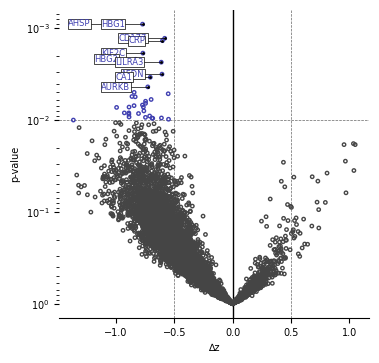

In [368]:
b_npm1_prot_top_up, b_npm1_prot_top_down = plot_volcano_and_select_top_features(
    b_npm1_prot,
    0.5,
    0.01,
    "B_NPM1-WT",
    "Proteomics"
)

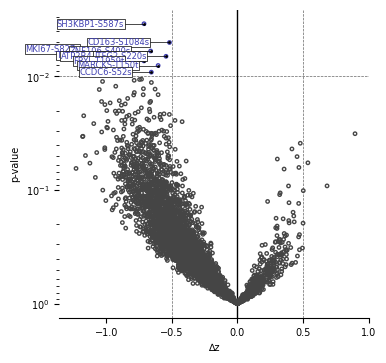

In [369]:
b_npm1_phos_top_up, b_npm1_phos_top_down = plot_volcano_and_select_top_features(
    b_npm1_phos,
    0.5,
    0.01,
    "B_NPM1-WT",
    "Phosphoproteomics"
)

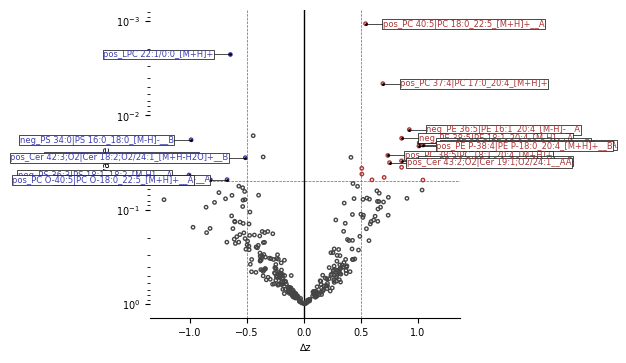

In [370]:
b_npm1_lipid_top_up, b_npm1_lipid_top_down = plot_volcano_and_select_top_features(
    b_npm1_lipid,
    0.5,
    0.05,
    "B_NPM1-WT",
    "Lipidomics"
)

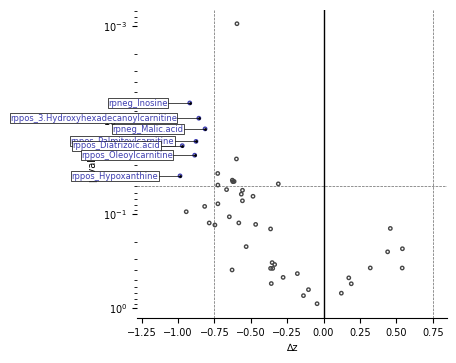

In [371]:
b_npm1_metab_top_up, b_npm1_metab_top_down = plot_volcano_and_select_top_features(
    b_npm1_metab,
    0.75,
    0.05,
    "B_NPM1-WT",
    "Metabolomics"
)

#### white patients

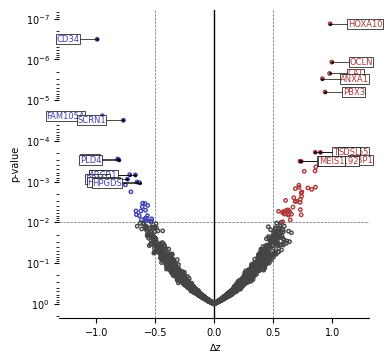

In [372]:
w_npm1_prot_top_up, w_npm1_prot_top_down = plot_volcano_and_select_top_features(
    w_npm1_prot,
    0.5,
    0.01,
    "W_NPM1-WT",
    "Proteomics"
)

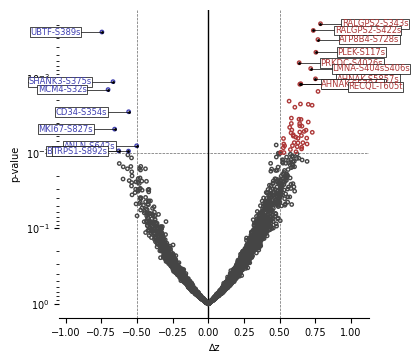

In [373]:
w_npm1_phos_top_up, w_npm1_phos_top_down = plot_volcano_and_select_top_features(
    w_npm1_phos,
    0.5,
    0.01,
    "W_NPM1-WT",
    "Phosphoproteomics"
)

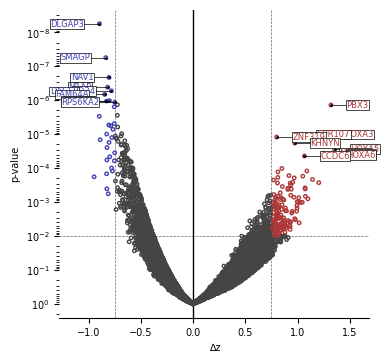

In [374]:
w_npm1_rna_top_up, w_npm1_rna_top_down = plot_volcano_and_select_top_features(
    w_npm1_rna,
    0.75,
    0.01,
    "W_NPM1-WT",
    "Transcriptomics"
)

### NRAS vs. WT

#### black patients

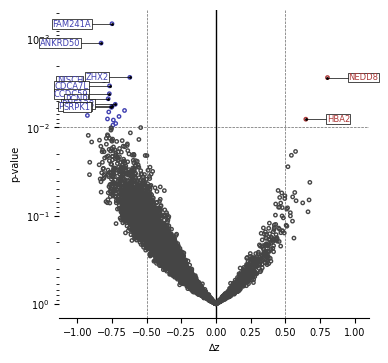

In [375]:
b_nras_prot_top_up, b_nras_prot_top_down = plot_volcano_and_select_top_features(
    b_nras_prot,
    0.5,
    0.01,
    "B_NRAS-WT",
    "Proteomics"
)

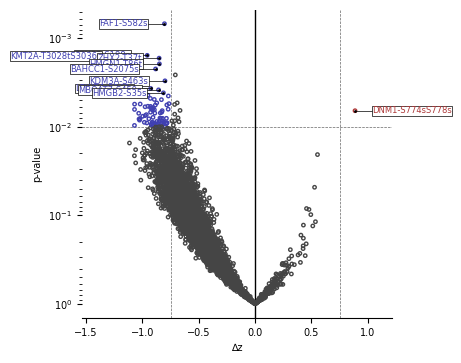

In [376]:
b_nras_phos_top_up, b_nras_phos_top_down = plot_volcano_and_select_top_features(
    b_nras_phos,
    0.75,
    0.01,
    "B_NRAS-WT",
    "Phosphoproteomics"
)

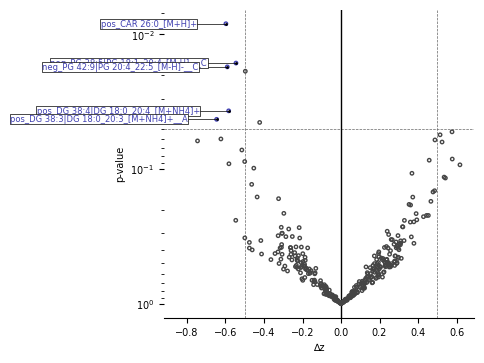

In [377]:
b_nras_lipid_top_up, b_nras_lipid_top_down = plot_volcano_and_select_top_features(
    b_nras_lipid,
    0.5,
    0.05,
    "B_NRAS-WT",
    "Lipidomics"
)

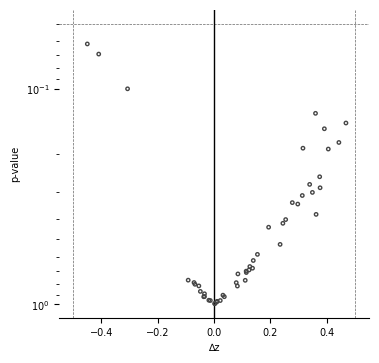

In [378]:
b_nras_metab_top_up, b_nras_metab_top_down = plot_volcano_and_select_top_features(
    b_nras_metab,
    0.5,
    0.05,
    "B_NRAS-WT",
    "Metabolomics"
)

#### white patients

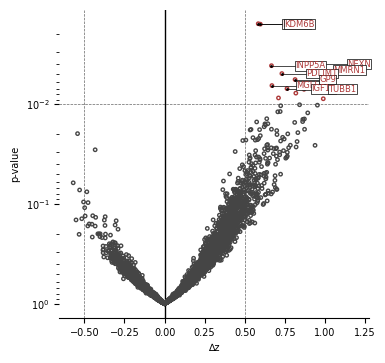

In [379]:
w_nras_prot_top_up, w_nras_prot_top_down = plot_volcano_and_select_top_features(
    w_nras_prot,
    0.5,
    0.01,
    "W_NRAS-WT",
    "Proteomics"
)

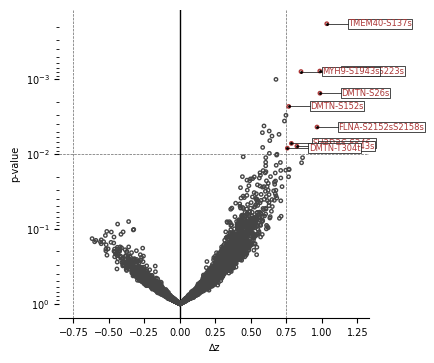

In [380]:
w_nras_phos_top_up, w_nras_phos_top_down = plot_volcano_and_select_top_features(
    w_nras_phos,
    0.75,
    0.01,
    "W_NRAS-WT",
    "Phosphoproteomics"
)

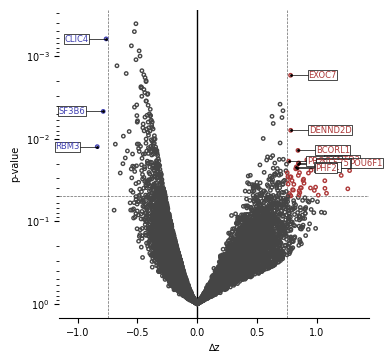

In [381]:
w_nras_rna_top_up, w_nras_rna_top_down = plot_volcano_and_select_top_features(
    w_nras_rna,
    0.75,
    0.05,
    "W_NRAS-WT",
    "Transcriptomics"
)

### FLT3-ITD vs. WT
#### black patients

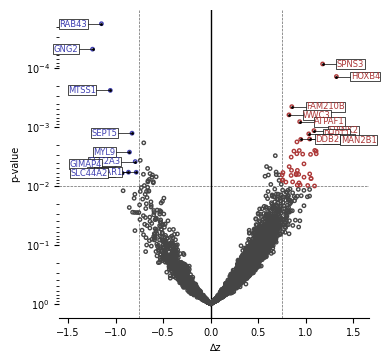

In [55]:
b_flt3itd_prot_top_up, b_flt3itd_prot_top_down = plot_volcano_and_select_top_features(
    b_flt3itd_prot,
    0.75,
    0.01,
    "B_FLT3-ITD-WT",
    "Proteomics"
)

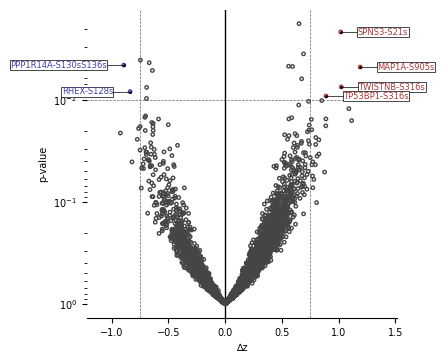

In [51]:
b_flt3itd_phos_top_up, b_flt3itd_phos_top_down = plot_volcano_and_select_top_features(
    b_flt3itd_phos,
    0.75,
    0.01,
    "B_FLT3-ITD-WT",
    "Phosphoproteomics"
)

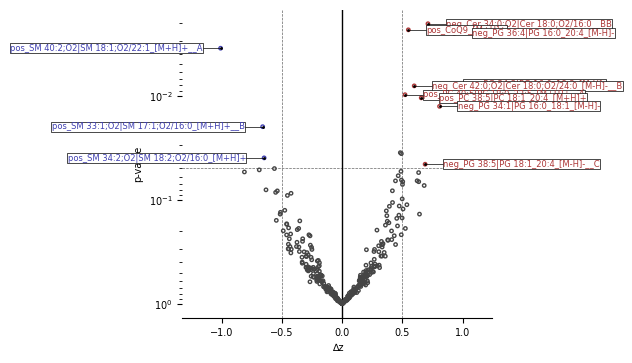

In [52]:
b_flt3itd_lipid_top_up, b_flt3itd_lipid_top_down = plot_volcano_and_select_top_features(
    b_flt3itd_lipid,
    0.5,
    0.05,
    "B_FLT3-ITD-WT",
    "Lipidomics"
)

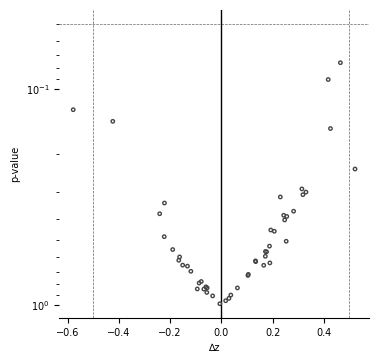

In [53]:
b_flt3itd_metab_top_up, b_flt3itd_metab_top_down = plot_volcano_and_select_top_features(
    b_flt3itd_metab,
    0.5,
    0.05,
    "B_FLT3-ITD-WT",
    "Metabolomics"
)

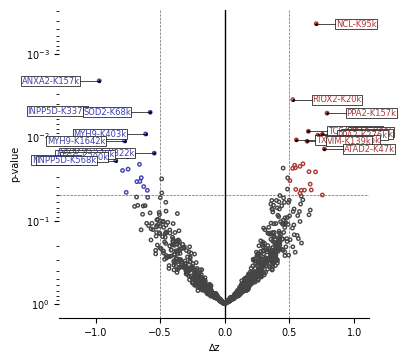

In [54]:
b_flt3itd_acetyl_top_up, b_flt3itd_acetyl_top_down = plot_volcano_and_select_top_features(
    b_flt3itd_acetyl,
    0.5,
    0.05,
    "B_FLT3-ITD-WT",
    "Acetylomics"
)

#### white patients

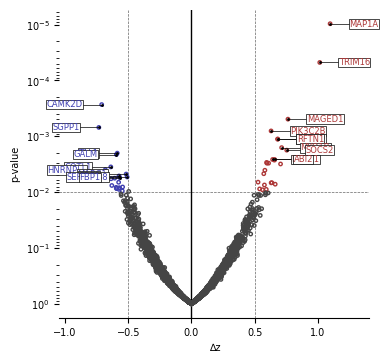

In [63]:
w_flt3itd_prot_top_up, w_flt3itd_prot_top_down = plot_volcano_and_select_top_features(
    w_flt3itd_prot,
    0.5,
    0.01,
    "W_FLT3-ITD-WT",
    "Proteomics"
)

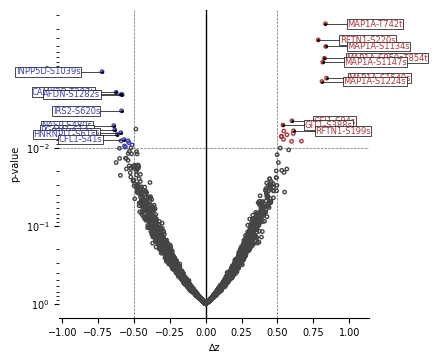

In [62]:
w_flt3itd_phos_top_up, w_flt3itd_phos_top_down = plot_volcano_and_select_top_features(
    w_flt3itd_phos,
    0.5,
    0.01,
    "W_FLT3-ITD-WT",
    "Phosphoproteomics"
)

### FLT3-ITDxNPM1 vs. WT
#### black patients

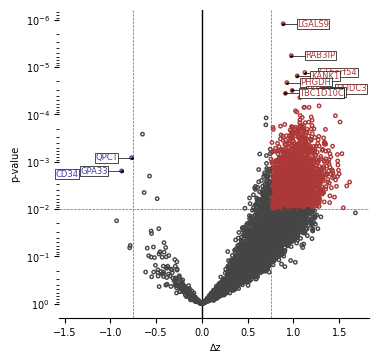

In [64]:
b_flt3itdnpm1_prot_top_up, b_flt3itdnpm1_prot_top_down = plot_volcano_and_select_top_features(
    b_flt3itdnpm1_prot,
    0.75,
    0.01,
    "B_FLT3-ITDxNPM1-WT",
    "Proteomics"
)

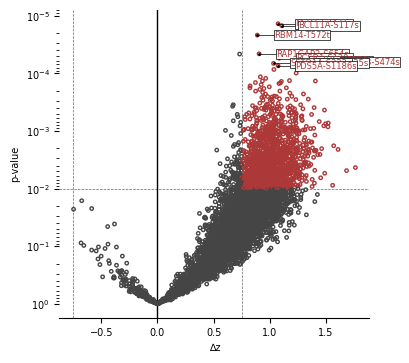

In [65]:
b_flt3itdnpm1_phos_top_up, b_flt3itdnpm1_phos_top_down = plot_volcano_and_select_top_features(
    b_flt3itdnpm1_phos,
    0.75,
    0.01,
    "B_FLT3-ITDxNPM1-WT",
    "Phosphoproteomics"
)

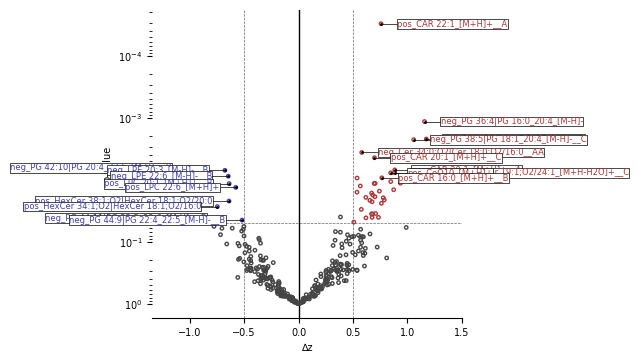

In [66]:
b_flt3itdnpm1_lipid_top_up, b_flt3itdnpm1_lipid_top_down = plot_volcano_and_select_top_features(
    b_flt3itdnpm1_lipid,
    0.5,
    0.05,
    "B_FLT3-ITDxNPM1-WT",
    "Lipidomics"
)

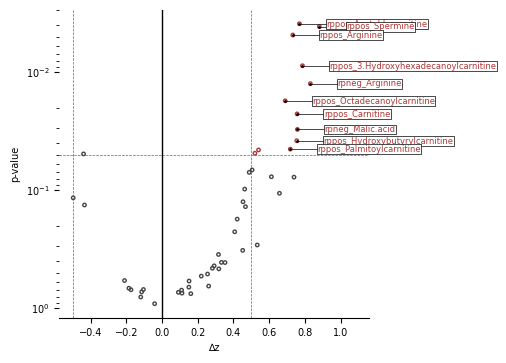

In [67]:
b_flt3itdnpm1_metab_top_up, b_flt3itdnpm1_metab_top_down = plot_volcano_and_select_top_features(
    b_flt3itdnpm1_metab,
    0.5,
    0.05,
    "B_FLT3-ITDxNPM1-WT",
    "Metabolomics"
)

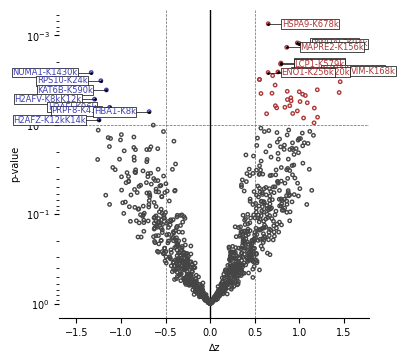

In [77]:
b_flt3itdnpm1_acetyl_top_up, b_flt3itdnpm1_acetyl_top_down = plot_volcano_and_select_top_features(
    b_flt3itdnpm1_acetyl,
    0.5,
    0.01,
    "B_FLT3-ITDxNPM1-WT",
    "Acetylomics"
)

#### white patients

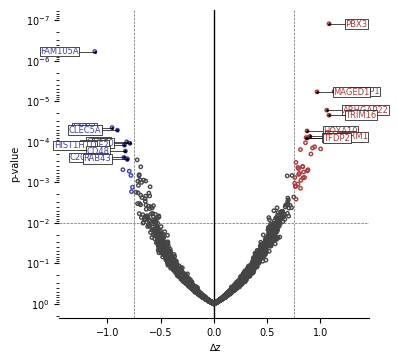

In [76]:
w_flt3itdnpm1_prot_top_up, w_flt3itdnpm1_prot_top_down = plot_volcano_and_select_top_features(
    w_flt3itdnpm1_prot,
    0.75,
    0.01,
    "W_FLT3-ITDxNPM1-WT",
    "Proteomics"
)

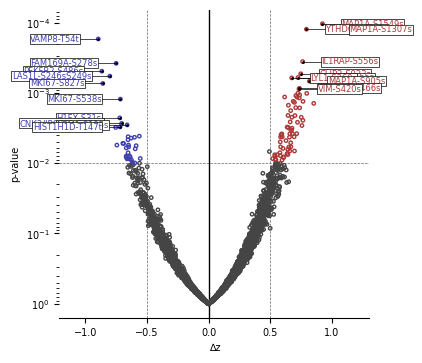

In [70]:
w_flt3itdnpm1_phos_top_up, w_flt3itdnpm1_phos_top_down = plot_volcano_and_select_top_features(
    w_flt3itdnpm1_phos,
    0.5,
    0.01,
    "W_FLT3-ITDxNPM1-WT",
    "Phosphoproteomics"
)

### Compare counts of selected features between black and white patients

#### NPM1

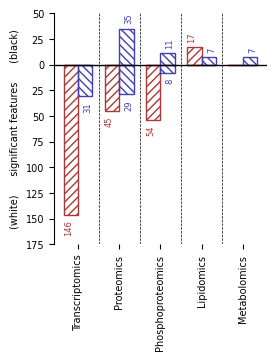

In [382]:
# bar data
x = list(range(1, 6)) * 2
all_up = [
    # black patients
    0, 
    len(b_npm1_prot_top_up),
    len(b_npm1_phos_top_up),
    len(b_npm1_lipid_top_up),
    len(b_npm1_metab_top_up),
    # white patients (negative values)
    -len(w_npm1_rna_top_up),
    -len(w_npm1_prot_top_up),
    -len(w_npm1_phos_top_up),
    0,
    0,
]
all_down = [
    # black patients
    0, 
    len(b_npm1_prot_top_down),
    len(b_npm1_phos_top_down),
    len(b_npm1_lipid_top_down),
    len(b_npm1_metab_top_down),
    # white patients (negative values)
    -len(w_npm1_rna_top_down),
    -len(w_npm1_prot_top_down),
    -len(w_npm1_phos_top_down),
    0,
    0,
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(2.75, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5, 3.5, 4.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### NRAS

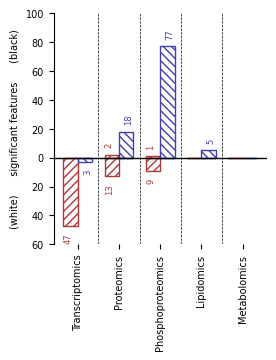

In [366]:
# bar data
x = list(range(1, 6)) * 2
all_up = [
    # black patients
    0, 
    len(b_nras_prot_top_up),
    len(b_nras_phos_top_up),
    len(b_nras_lipid_top_up),
    len(b_nras_metab_top_up),
    # white patients (negative values)
    -len(w_nras_rna_top_up),
    -len(w_nras_prot_top_up),
    -len(w_nras_phos_top_up),
    0,
    0,
]
all_down = [
    # black patients
    0, 
    len(b_nras_prot_top_down),
    len(b_nras_phos_top_down),
    len(b_nras_lipid_top_down),
    len(b_nras_metab_top_down),
    # white patients (negative values)
    -len(w_nras_rna_top_down),
    -len(w_nras_prot_top_down),
    -len(w_nras_phos_top_down),
    0,
    0,
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(2.75, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5, 3.5, 4.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NRAS-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITD

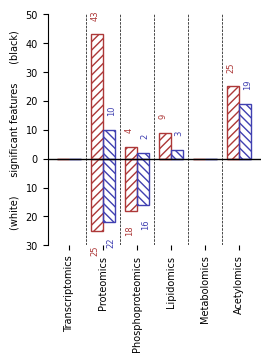

In [75]:
# bar data
x = list(range(1, 7)) * 2
all_up = [
    # black patients
    0, 
    len(b_flt3itd_prot_top_up),
    len(b_flt3itd_phos_top_up),
    len(b_flt3itd_lipid_top_up),
    len(b_flt3itd_metab_top_up),
    len(b_flt3itd_acetyl_top_up),
    # white patients (negative values)
    0,
    -len(w_flt3itd_prot_top_up),
    -len(w_flt3itd_phos_top_up),
    0,
    0,
    0
]
all_down = [
    # black patients
    0, 
    len(b_flt3itd_prot_top_down),
    len(b_flt3itd_phos_top_down),
    len(b_flt3itd_lipid_top_down),
    len(b_flt3itd_metab_top_down),
    len(b_flt3itd_acetyl_top_down),
    # white patients (negative values)
    0,
    -len(w_flt3itd_prot_top_down),
    -len(w_flt3itd_phos_top_down),
    0,
    0,
    0
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(2.75, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics",
        "Acetylomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITD-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITDxNPM1 vs. WT

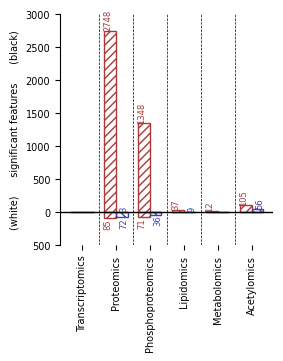

In [74]:
# bar data
x = list(range(1, 7)) * 2
all_up = [
    # black patients
    0, 
    len(b_flt3itdnpm1_prot_top_up),
    len(b_flt3itdnpm1_phos_top_up),
    len(b_flt3itdnpm1_lipid_top_up),
    len(b_flt3itdnpm1_metab_top_up),
    len(b_flt3itdnpm1_acetyl_top_up),
    # white patients (negative values)
    0,
    -len(w_flt3itdnpm1_prot_top_up),
    -len(w_flt3itdnpm1_phos_top_up),
    0,
    0,
    0
]
all_down = [
    # black patients
    0, 
    len(b_flt3itdnpm1_prot_top_down),
    len(b_flt3itdnpm1_phos_top_down),
    len(b_flt3itdnpm1_lipid_top_down),
    len(b_flt3itdnpm1_metab_top_down),
    len(b_flt3itdnpm1_acetyl_top_down),
    # white patients (negative values)
    0,
    -len(w_flt3itdnpm1_prot_top_down),
    -len(w_flt3itdnpm1_phos_top_down),
    0,
    0,
    0
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(2.75, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics",
        "Acetylomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITDxNPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


In [78]:
set(b_flt3itd_prot_top_up["Feature"].to_list()) &  set(w_flt3itd_prot_top_up["Feature"].to_list())

{'FAH', 'MAGED1', 'PRODH'}

In [79]:
set(b_flt3itd_prot_top_down["Feature"].to_list()) &  set(w_flt3itd_prot_top_down["Feature"].to_list())

set()